In [1]:
# ============================================
# PHASE 1: DATA UNDERSTANDING & CLEANING
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
# Load dataset
file_path = "/content/Sample - Superstore.csv.zip"

df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Dataset Dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 9994
Number of columns: 21


In [4]:
# View the data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [5]:
# Understand the Columns
print("Column names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

# Check datatypes
df.info()

Column names:
1. Row ID
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID
7. Customer Name
8. Segment
9. Country
10. City
11. State
12. Postal Code
13. Region
14. Product ID
15. Category
16. Sub-Category
17. Product Name
18. Sales
19. Quantity
20. Discount
21. Profit
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   

In [6]:
# Convert Dates
# Convert date columns to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Verify the order date and ship date
print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [7]:
# checking the date range
print("Minimum Order Date:", df["Order Date"].min())
print("Maximum Order Date:", df["Order Date"].max())

# roughly four years of historical sales data.

Minimum Order Date: 2014-01-03 00:00:00
Maximum Order Date: 2017-12-30 00:00:00


In [8]:
# Check missing values and duplicate records
missing_values = df.isnull().sum()
print(missing_values)

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Number of duplicate rows: 0


In [9]:
# Check unique values (it will be best to understand the categorical variables)
categorical_columns = [
    "Ship Mode",
    "Segment",
    "Country",
    "Region",
    "Category",
    "Sub-Category"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


Ship Mode
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Segment
['Consumer' 'Corporate' 'Home Office']

Country
['United States']

Region
['South' 'West' 'Central' 'East']

Category
['Furniture' 'Office Supplies' 'Technology']

Sub-Category
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


In [10]:
# Summary
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994,9994,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.38,229.86,3.79,0.16,28.66
min,1.00,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.00,209.94,5.00,0.20,29.36
max,9994.00,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.00,22638.48,14.00,0.80,8399.98
std,2885.16,NaN,NaN,32063.69,623.25,2.23,0.21,234.26


In [11]:
# We should check whether values that should logically be positive are actually positive.

# Sales
print("Sales <= 0:", (df["Sales"] <= 0).sum())

# Quantity
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())

# Discount
print("Discount < 0:", (df["Discount"] < 0).sum())
print("Discount > 1:", (df["Discount"] > 1).sum())

Sales <= 0: 0
Quantity <= 0: 0
Discount < 0: 0
Discount > 1: 0


In [12]:
# Check Chronological Ordering
is_sorted = df["Order Date"].is_monotonic_increasing

print("Is data chronologically sorted?", is_sorted)

# If false, then sort it
df = df.sort_values("Order Date").reset_index(drop=True)

# And verify it
print("Data sorted by Order Date.")
print(df[["Order Date", "Sales"]].head())

Is data chronologically sorted? False
Data sorted by Order Date.
  Order Date  Sales
0 2014-01-03  16.45
1 2014-01-04  11.78
2 2014-01-04 272.74
3 2014-01-04   3.54
4 2014-01-05  19.54


In [13]:
# clean dataset summary
summary = {
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Start Date": df["Order Date"].min(),
    "End Date": df["Order Date"].max(),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Unique Orders": df["Order ID"].nunique(),
    "Unique Customers": df["Customer ID"].nunique(),
    "Unique Products": df["Product ID"].nunique(),
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Rows,9994
1,Columns,21
2,Start Date,2014-01-03 00:00:00
3,End Date,2017-12-30 00:00:00
4,Missing Values,0
5,Duplicate Rows,0
6,Unique Orders,5009
7,Unique Customers,793
8,Unique Products,1862
9,Total Sales,2297200.86


In [14]:
# Final Validation
print("=" * 50)
print("FINAL DATASET VALIDATION")
print("=" * 50)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Date Range: {df['Order Date'].min().date()} "
      f"to {df['Order Date'].max().date()}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Unique Orders: {df['Order ID'].nunique():,}")
print(f"Unique Customers: {df['Customer ID'].nunique():,}")
print(f"Unique Products: {df['Product ID'].nunique():,}")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")

print("=" * 50)
print("PHASE 1 COMPLETED")
print("=" * 50)

FINAL DATASET VALIDATION
Rows: 9,994
Columns: 21
Date Range: 2014-01-03 to 2017-12-30
Missing Values: 0
Duplicate Rows: 0
Unique Orders: 5,009
Unique Customers: 793
Unique Products: 1,862
Total Sales: $2,297,200.86
Total Profit: $286,397.02
PHASE 1 COMPLETED


In [15]:
# ============================================
# PHASE 2: EDA & TIME-SERIES UNDERSTANDING
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Plot configuration
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

In [16]:
# We have created time based columns

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter
df["Day"] = df["Order Date"].dt.day
df["Day of Week"] = df["Order Date"].dt.dayofweek
df["Day Name"] = df["Order Date"].dt.day_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Day,Day of Week,Day Name
0,7981,CA-2014-103800,2014-01-03,2014-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55,2014,1,January,1,3,4,Friday
1,740,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27,2014,1,January,1,4,5,Saturday
2,741,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.20,-64.77,2014,1,January,1,4,5,Saturday
3,742,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49,2014,1,January,1,4,5,Saturday
4,1760,CA-2014-141817,2014-01-05,2014-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.20,4.88,2014,1,January,1,5,6,Sunday


In [17]:
# Aggregate sales by month

monthly_sales = (
    df.set_index("Order Date")
      .resample("MS")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head(12)

,Order Date,Sales
0,2014-01-01,14236.90
1,2014-02-01,4519.89
2,2014-03-01,55691.01
3,2014-04-01,28295.35
4,2014-05-01,23648.29
5,2014-06-01,34595.13
6,2014-07-01,33946.39
7,2014-08-01,27909.47
8,2014-09-01,81777.35
9,2014-10-01,31453.39


In [18]:
# Monthly Dataset
print("Number of monthly observations:", len(monthly_sales))

print(
    "Date range:",
    monthly_sales["Order Date"].min().date(),
    "to",
    monthly_sales["Order Date"].max().date()
)

Number of monthly observations: 48
Date range: 2014-01-01 to 2017-12-01


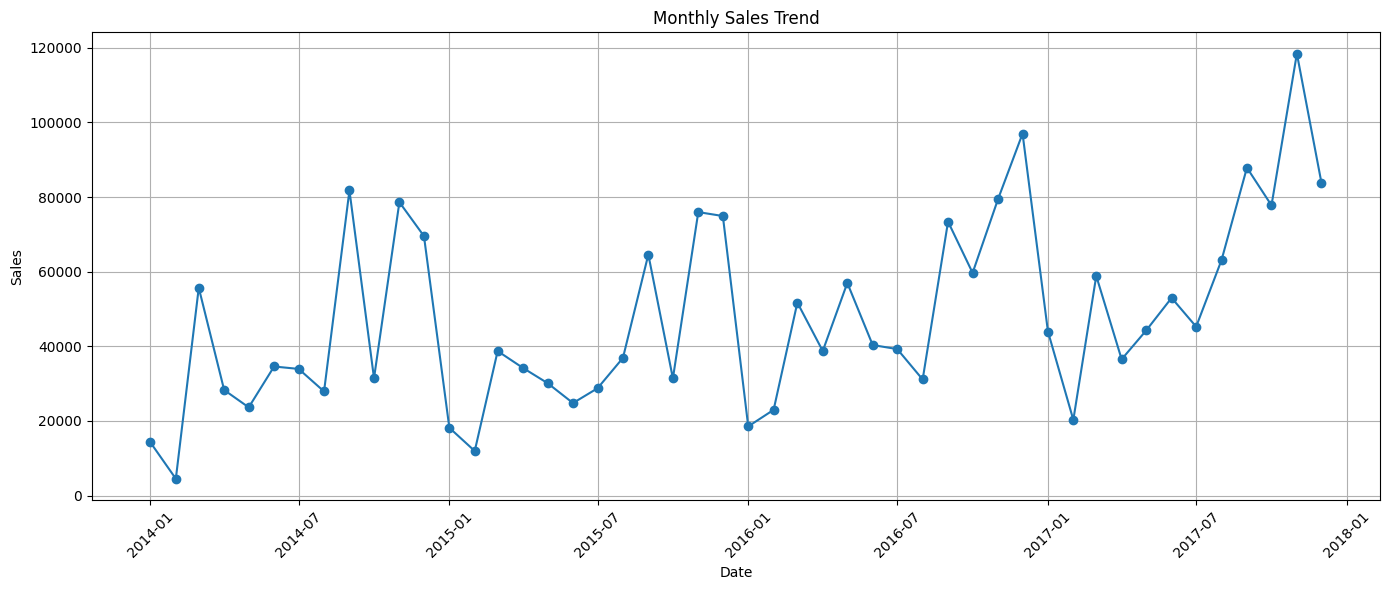

In [19]:
# Plotting overall Sales Data
# Question:- Is the business sales trend increasing or decreasing
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

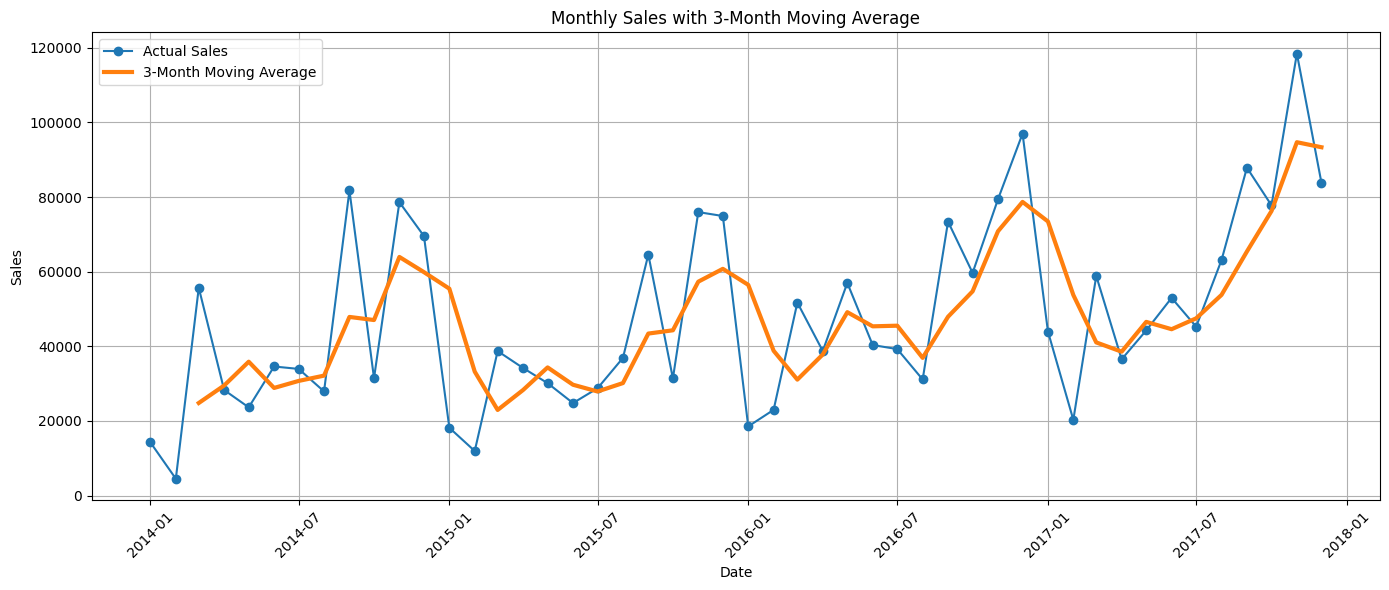

In [20]:
# Add a moving average
# A moving average helps us distinguish the underlying trend from short-term fluctuations.

# Calculating 3 month moving average
monthly_sales["3_Month_MA"] = (
    monthly_sales["Sales"]
    .rolling(window=3)
    .mean()
)

# plot
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["3_Month_MA"],
    linewidth=3,
    label="3-Month Moving Average"
)

plt.title("Monthly Sales with 3-Month Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

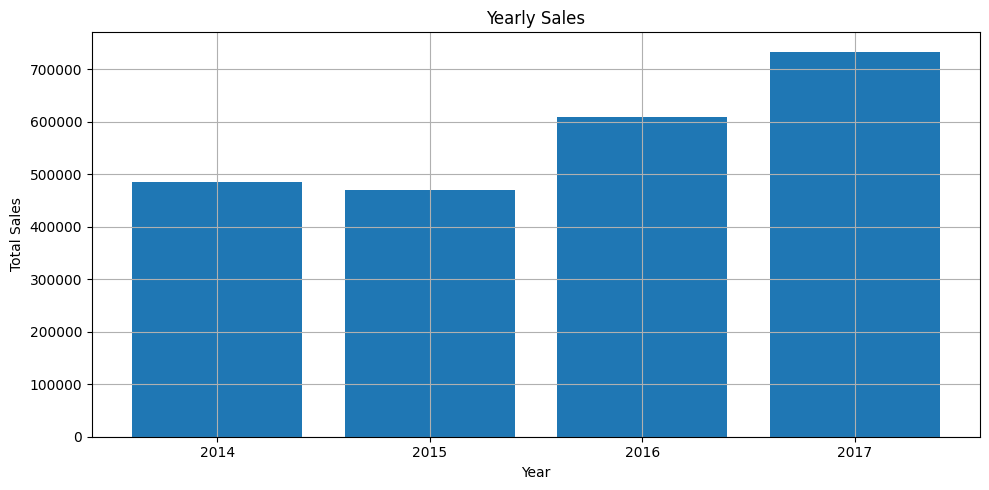

In [21]:
# Analyze yearly sales
yearly_sales = (
    df.groupby("Year")["Sales"]
      .sum()
      .reset_index()
)

yearly_sales

# plot it
plt.figure(figsize=(10, 5))

plt.bar(
    yearly_sales["Year"].astype(str),
    yearly_sales["Sales"]
)

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [22]:
# Calculate year-over-year growth:
yearly_sales["YoY Growth (%)"] = (
    yearly_sales["Sales"]
    .pct_change()
    .mul(100)
)

yearly_sales

,Year,Sales,YoY Growth (%)
0,2014,484247.50,NaN
1,2015,470532.51,-2.83
2,2016,609205.60,29.47
3,2017,733215.26,20.36


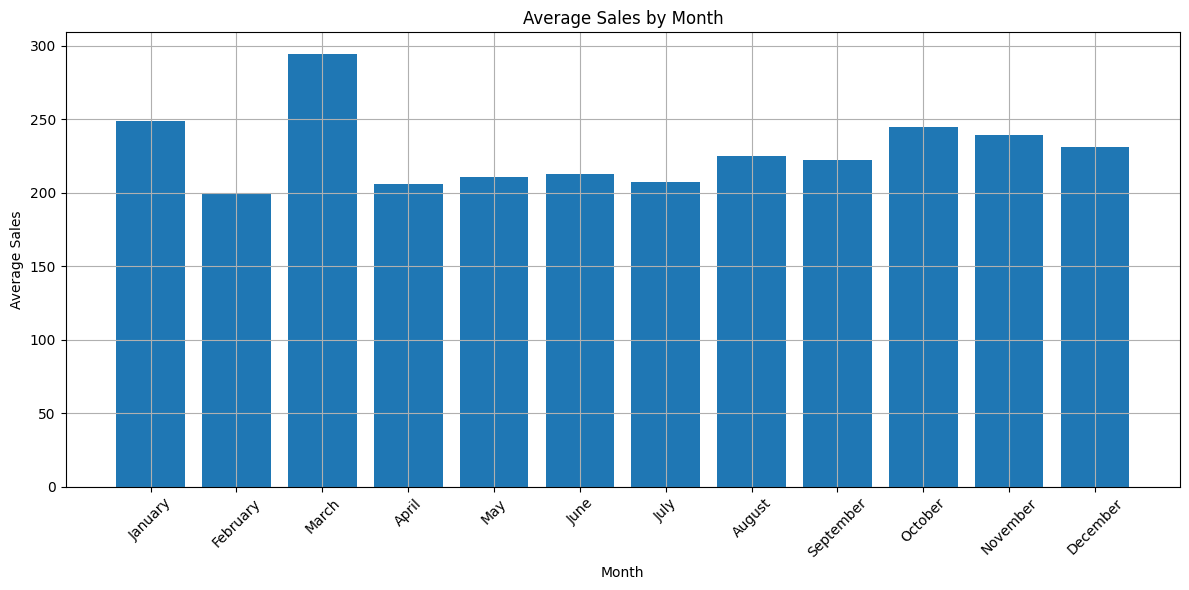

In [23]:
# Analyze monthly seasonality
# Calculate average sales for each calender month
monthly_seasonality = (
    df.groupby(["Month", "Month Name"])["Sales"]
      .mean()
      .reset_index()
      .sort_values("Month")
)

monthly_seasonality

# plot it
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_seasonality["Month Name"],
    monthly_seasonality["Sales"]
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

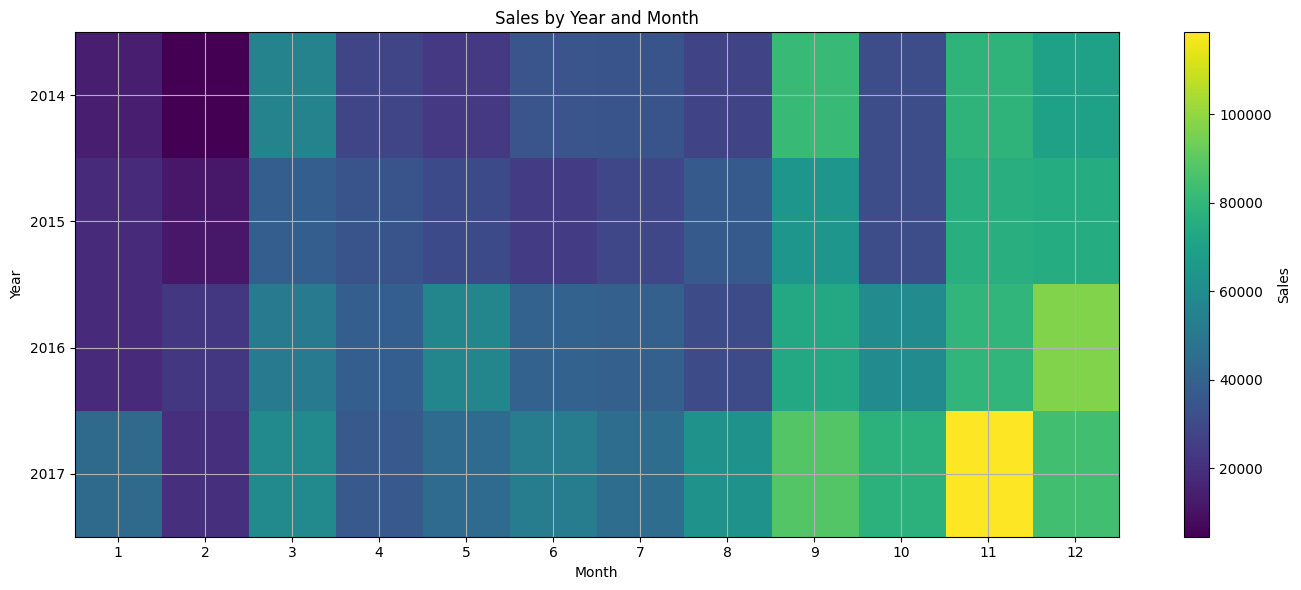

In [24]:
# Year * Month Analysis
# Creating pivot table

year_month_sales = pd.pivot_table(
    df,
    values="Sales",
    index="Year",
    columns="Month",
    aggfunc="sum"
)

year_month_sales

# plot it

plt.figure(figsize=(14, 6))

plt.imshow(
    year_month_sales,
    aspect="auto"
)

plt.colorbar(label="Sales")

plt.title("Sales by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")

plt.xticks(
    range(len(year_month_sales.columns)),
    year_month_sales.columns
)

plt.yticks(
    range(len(year_month_sales.index)),
    year_month_sales.index
)

plt.tight_layout()
plt.show()

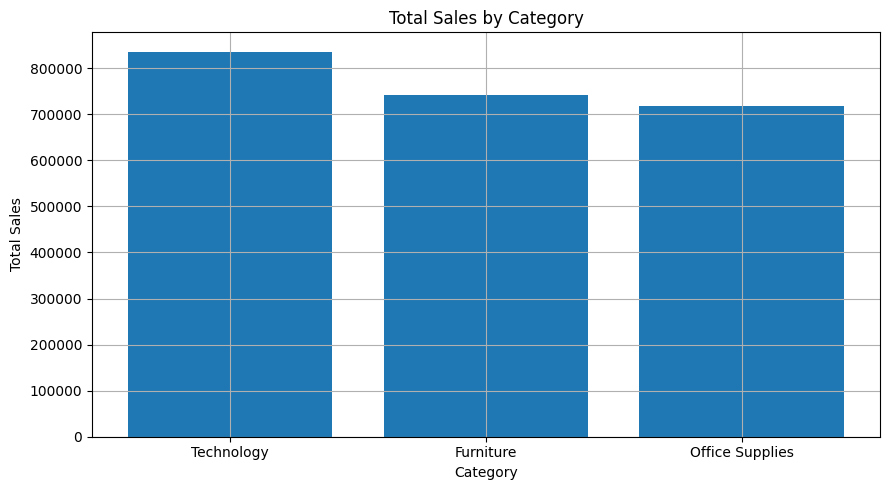

In [25]:
# Category sales analysis
# lets calculate their total sales

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales

# plot it

plt.figure(figsize=(9, 5))

plt.bar(
    category_sales["Category"],
    category_sales["Sales"]
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

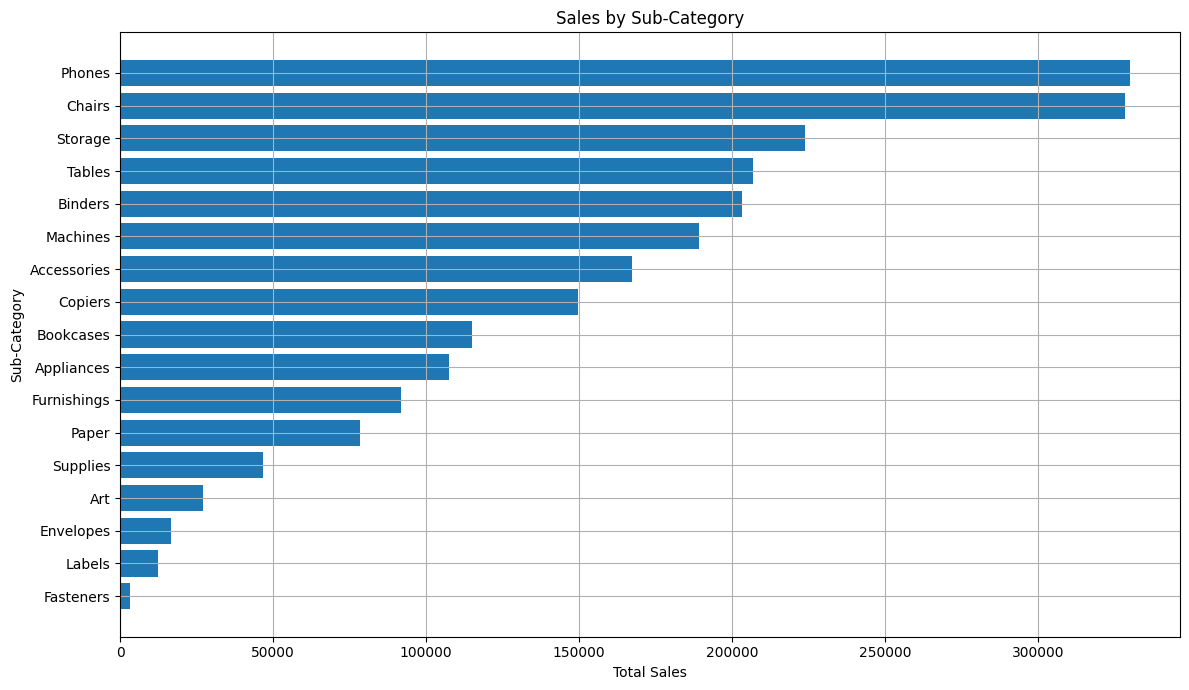

In [26]:
# Sub-Category Analysis
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

subcategory_sales

# plot it
plt.figure(figsize=(12, 7))

plt.barh(
    subcategory_sales["Sub-Category"],
    subcategory_sales["Sales"]
)

plt.title("Sales by Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

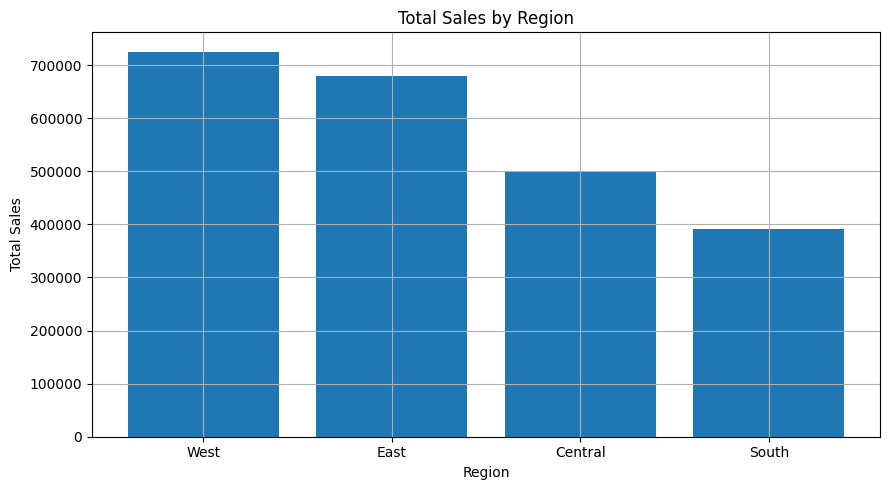

In [27]:
# Regional Sales Analysis
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

region_sales

# plot it

plt.figure(figsize=(9, 5))

plt.bar(
    region_sales["Region"],
    region_sales["Sales"]
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

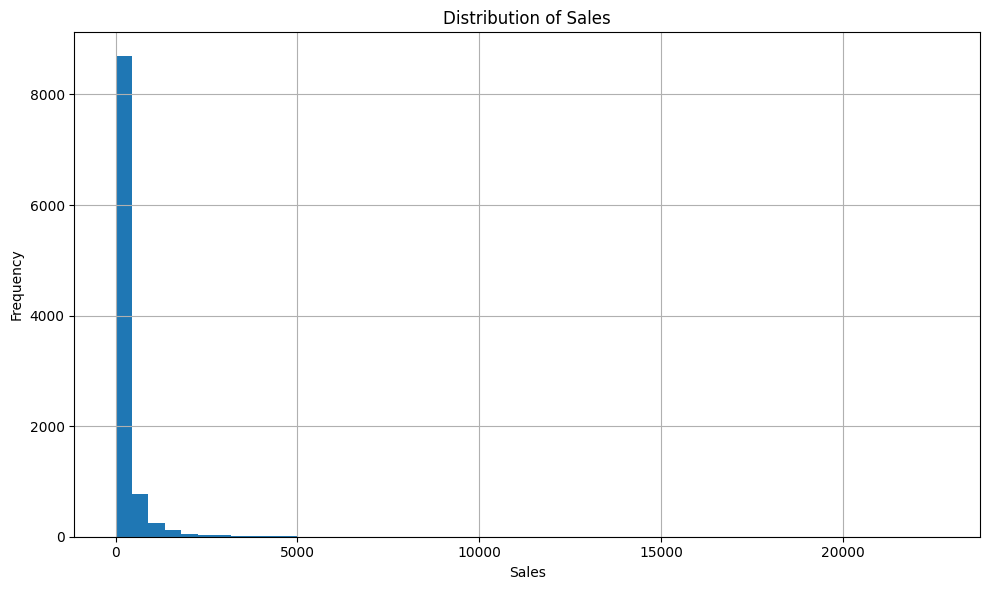

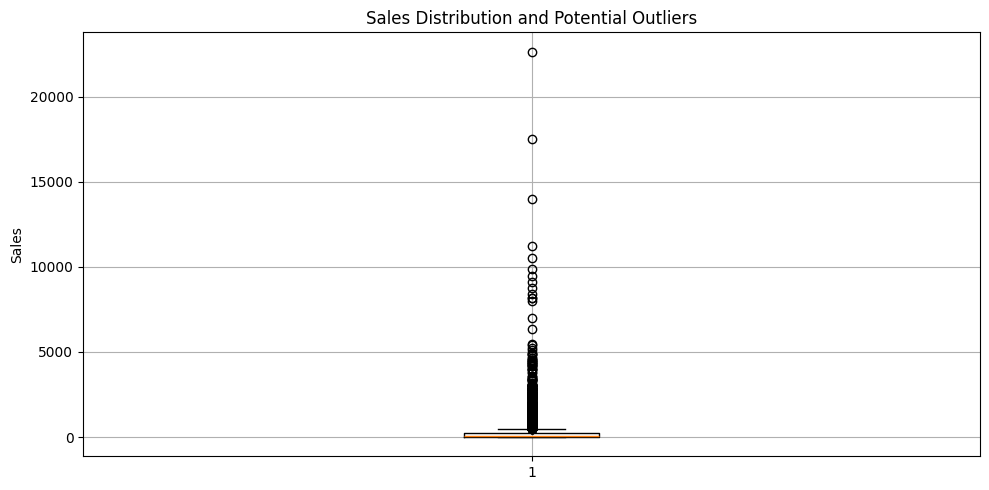

In [28]:
# Analyze sales distribution
plt.figure(figsize=(10, 6))

plt.hist(
    df["Sales"],
    bins=50
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# plot it

plt.figure(figsize=(10, 5))

plt.boxplot(df["Sales"])

plt.title("Sales Distribution and Potential Outliers")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

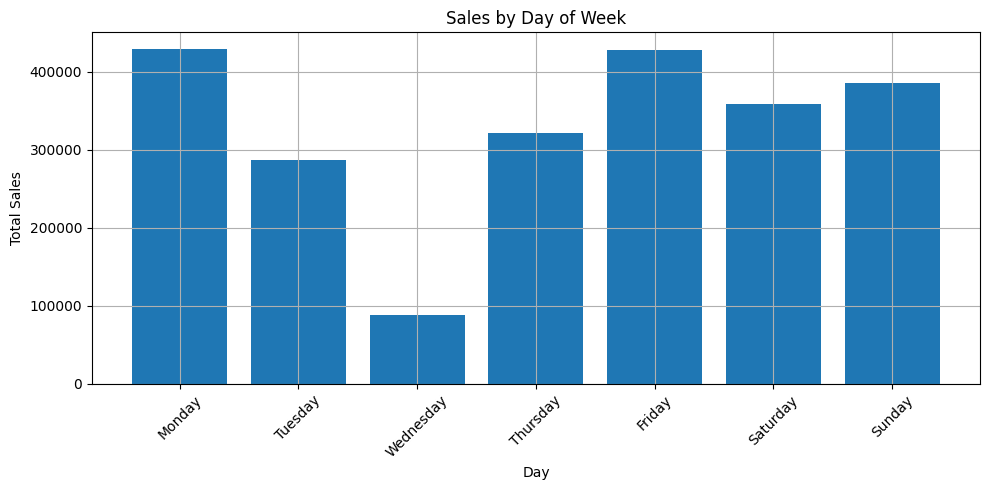

In [29]:
# Analyze sales by day of week
day_sales = (
    df.groupby(["Day of Week", "Day Name"])["Sales"]
      .sum()
      .reset_index()
      .sort_values("Day of Week")
)

day_sales

# plot it
plt.figure(figsize=(10, 5))

plt.bar(
    day_sales["Day Name"],
    day_sales["Sales"]
)

plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [30]:
# Analyze Monthy sales Variability
monthly_sales["Sales"].describe()

print("Mean monthly sales:",
      monthly_sales["Sales"].mean())

print("Median monthly sales:",
      monthly_sales["Sales"].median())

print("Standard deviation:",
      monthly_sales["Sales"].std())

print("Minimum monthly sales:",
      monthly_sales["Sales"].min())

print("Maximum monthly sales:",
      monthly_sales["Sales"].max())

Mean monthly sales: 47858.35125625
Median monthly sales: 39803.2485
Standard deviation: 25195.890699956268
Minimum monthly sales: 4519.892
Maximum monthly sales: 118447.825


In [31]:
# Find Highest and Lowest sales months
highest_month = monthly_sales.loc[
    monthly_sales["Sales"].idxmax()
]

print("Highest Sales Month:")
print(highest_month)

lowest_month = monthly_sales.loc[
    monthly_sales["Sales"].idxmin()
]

print("Lowest Sales Month:")
print(lowest_month)

Highest Sales Month:
Order Date    2017-11-01 00:00:00
Sales                   118447.82
3_Month_MA               94697.13
Name: 46, dtype: object
Lowest Sales Month:
Order Date    2014-02-01 00:00:00
Sales                     4519.89
3_Month_MA                    NaN
Name: 1, dtype: object


In [32]:
# Creating clean forecasting dataset
forecast_df = monthly_sales[
    ["Order Date", "Sales"]
].copy()

forecast_df.head()

# Rename the date column
forecast_df = forecast_df.rename(
    columns={
        "Order Date": "Date"
    }
)

forecast_df.head()

# Set the date as index
forecast_df = forecast_df.set_index("Date")

forecast_df.head()

forecast_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2014-01-01 to 2017-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes


In [33]:
# Final Phase 2 Validation
print("=" * 60)
print("PHASE 2 — TIME SERIES DATA VALIDATION")
print("=" * 60)

print(f"Number of monthly observations: {len(forecast_df)}")
print(f"Start date: {forecast_df.index.min().date()}")
print(f"End date: {forecast_df.index.max().date()}")
print(f"Missing values: {forecast_df.isnull().sum().sum()}")
print(f"Duplicate dates: {forecast_df.index.duplicated().sum()}")

print("\nSales Statistics:")
print(f"Average monthly sales: ${forecast_df['Sales'].mean():,.2f}")
print(f"Minimum monthly sales: ${forecast_df['Sales'].min():,.2f}")
print(f"Maximum monthly sales: ${forecast_df['Sales'].max():,.2f}")

print("=" * 60)
print("PHASE 2 COMPLETED")
print("=" * 60)

PHASE 2 — TIME SERIES DATA VALIDATION
Number of monthly observations: 48
Start date: 2014-01-01
End date: 2017-12-01
Missing values: 0
Duplicate dates: 0

Sales Statistics:
Average monthly sales: $47,858.35
Minimum monthly sales: $4,519.89
Maximum monthly sales: $118,447.82
PHASE 2 COMPLETED


In [34]:
# ============================================
# PHASE 3: TIME-BASED FEATURE ENGINEERING
# ============================================

print(forecast_df.head())
print("\nShape:", forecast_df.shape)

              Sales
Date               
2014-01-01 14236.90
2014-02-01  4519.89
2014-03-01 55691.01
2014-04-01 28295.35
2014-05-01 23648.29

Shape: (48, 1)


In [35]:
# Making a seperate copy
# Gives the seperate dataset for machine learning
ml_df = forecast_df.copy()

print(ml_df.head())

              Sales
Date               
2014-01-01 14236.90
2014-02-01  4519.89
2014-03-01 55691.01
2014-04-01 28295.35
2014-05-01 23648.29


In [36]:
# Creating Calender Features, extracting information from the date
ml_df["Year"] = ml_df.index.year
ml_df["Month"] = ml_df.index.month
ml_df["Quarter"] = ml_df.index.quarter

ml_df.head()

,Sales,Year,Month,Quarter
Date,,,,
2014-01-01,14236.90,2014,1,1
2014-02-01,4519.89,2014,2,1
2014-03-01,55691.01,2014,3,1
2014-04-01,28295.35,2014,4,2
2014-05-01,23648.29,2014,5,2


In [37]:
# Create a Time Trend Features
ml_df["Trend"] = np.arange(1, len(ml_df) + 1)
# Check
ml_df[["Sales", "Year", "Month", "Quarter", "Trend"]].head(10)

,Sales,Year,Month,Quarter,Trend
Date,,,,,
2014-01-01,14236.90,2014,1,1,1
2014-02-01,4519.89,2014,2,1,2
2014-03-01,55691.01,2014,3,1,3
2014-04-01,28295.35,2014,4,2,4
2014-05-01,23648.29,2014,5,2,5
2014-06-01,34595.13,2014,6,2,6
2014-07-01,33946.39,2014,7,3,7
2014-08-01,27909.47,2014,8,3,8
2014-09-01,81777.35,2014,9,3,9


In [38]:
# Create a Lag Features
# Lag 1
ml_df["Lag_1"] = ml_df["Sales"].shift(1)

# Lag 2
ml_df["Lag_2"] = ml_df["Sales"].shift(2)

# Lag 3
ml_df["Lag_3"] = ml_df["Sales"].shift(3)

# Lag 6
ml_df["Lag_6"] = ml_df["Sales"].shift(6)

# Lag 12
ml_df["Lag_12"] = ml_df["Sales"].shift(12)

# Put them together
ml_df[
    [
        "Sales",
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Lag_6",
        "Lag_12"
    ]
].head(15)

,Sales,Lag_1,Lag_2,Lag_3,Lag_6,Lag_12
Date,,,,,,
2014-01-01,14236.90,NaN,NaN,NaN,NaN,NaN
2014-02-01,4519.89,14236.90,NaN,NaN,NaN,NaN
2014-03-01,55691.01,4519.89,14236.90,NaN,NaN,NaN
2014-04-01,28295.35,55691.01,4519.89,14236.90,NaN,NaN
2014-05-01,23648.29,28295.35,55691.01,4519.89,NaN,NaN
2014-06-01,34595.13,23648.29,28295.35,55691.01,NaN,NaN
2014-07-01,33946.39,34595.13,23648.29,28295.35,14236.90,NaN
2014-08-01,27909.47,33946.39,34595.13,23648.29,4519.89,NaN
2014-09-01,81777.35,27909.47,33946.39,34595.13,55691.01,NaN


In [40]:
# Create Rolling Features
# 3 month rolling average

ml_df["Rolling_Mean_3"] = (
    ml_df["Sales"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

# 6 month rolling average
ml_df["Rolling_Mean_6"] = (
    ml_df["Sales"]
    .shift(1)
    .rolling(window=6)
    .mean()
)

# 12 month rolling average
ml_df["Rolling_Mean_12"] = (
    ml_df["Sales"]
    .shift(1)
    .rolling(window=12)
    .mean()
)

In [41]:
# Rolling Standard Deviation

ml_df["Rolling_Std_3"] = (
    ml_df["Sales"]
    .shift(1)
    .rolling(window=3)
    .std()
)

ml_df["Rolling_Std_6"] = (
    ml_df["Sales"]
    .shift(1)
    .rolling(window=6)
    .std()
)

In [44]:
# Create month seasonality features
# But month is technically a cyclical variable December (12) and January (1) are actually adjacent in the yearly cycle.

# A better representation is using sine/cosine encoding.

# Sine
ml_df["Month_Sin"] = np.sin(
    2 * np.pi * ml_df["Month"] / 12
)

# Cosine
ml_df["Month_Cos"] = np.cos(
    2 * np.pi * ml_df["Month"] / 12
)

ml_df.head(15)

,Sales,Year,Month,Quarter,Trend,Lag_1,Lag_2,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Mean_6,Rolling_Mean_12,Rolling_Std_3,Rolling_Std_6,Month_Sin,Month_Cos
Date,,,,,,,,,,,,,,,,,
2014-01-01,14236.90,2014,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.50,0.87
2014-02-01,4519.89,2014,2,1,2,14236.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.87,0.50
2014-03-01,55691.01,2014,3,1,3,4519.89,14236.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,0.00
2014-04-01,28295.35,2014,4,2,4,55691.01,4519.89,14236.90,NaN,NaN,24815.93,NaN,NaN,27176.42,NaN,0.87,-0.50
2014-05-01,23648.29,2014,5,2,5,28295.35,55691.01,4519.89,NaN,NaN,29502.08,NaN,NaN,25606.89,NaN,0.50,-0.87
2014-06-01,34595.13,2014,6,2,6,23648.29,28295.35,55691.01,NaN,NaN,35878.21,NaN,NaN,17314.99,NaN,0.00,-1.00
2014-07-01,33946.39,2014,7,3,7,34595.13,23648.29,28295.35,14236.90,NaN,28846.25,26831.09,NaN,5494.17,17674.01,-0.50,-0.87
2014-08-01,27909.47,2014,8,3,8,33946.39,34595.13,23648.29,4519.89,NaN,30729.94,30116.01,NaN,6141.46,16668.07,-0.87,-0.50
2014-09-01,81777.35,2014,9,3,9,27909.47,33946.39,34595.13,55691.01,NaN,32150.33,34014.27,NaN,3686.99,11381.14,-1.00,-0.00


In [45]:
# Inspect all features

print("Number of features:", ml_df.shape[1])
print("\nFeature names:")
print(ml_df.columns.tolist())

Number of features: 17

Feature names:
['Sales', 'Year', 'Month', 'Quarter', 'Trend', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_6', 'Lag_12', 'Rolling_Mean_3', 'Rolling_Mean_6', 'Rolling_Mean_12', 'Rolling_Std_3', 'Rolling_Std_6', 'Month_Sin', 'Month_Cos']


In [46]:
ml_df.isnull().sum()

,0
Sales,0
Year,0
Month,0
Quarter,0
Trend,0
Lag_1,1
Lag_2,2
Lag_3,3
Lag_6,6
Lag_12,12


In [51]:
# Remove Rows without sufficient history
ml_df = ml_df.dropna().copy()

print("Shape after removing NaN rows:", ml_df.shape)

ml_df.head()


Shape after removing NaN rows: (36, 17)


,Sales,Year,Month,Quarter,Trend,Lag_1,Lag_2,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Mean_6,Rolling_Mean_12,Rolling_Std_3,Rolling_Std_6,Month_Sin,Month_Cos
Date,,,,,,,,,,,,,,,,,
2015-01-01,18174.08,2015,1,1,13,69545.62,78628.72,31453.39,33946.39,14236.90,59875.91,53876.82,40353.96,25030.09,25341.44,0.50,0.87
2015-02-01,11951.41,2015,2,1,14,18174.08,69545.62,78628.72,27909.47,4519.89,55449.47,51248.10,40682.06,32599.34,28449.77,0.87,0.50
2015-03-01,38726.25,2015,3,1,15,11951.41,18174.08,69545.62,81777.35,55691.01,33223.70,48588.43,41301.35,31609.20,31635.55,1.00,0.00
2015-04-01,34195.21,2015,4,2,16,38726.25,11951.41,18174.08,31453.39,28295.35,22950.58,41413.24,39887.62,14011.93,27169.46,0.87,-0.50
2015-05-01,30131.69,2015,5,2,17,34195.21,38726.25,11951.41,78628.72,23648.29,28290.96,41870.21,40379.28,14330.67,26990.92,0.50,-0.87


In [52]:
ml_df.tail()

,Sales,Year,Month,Quarter,Trend,Lag_1,Lag_2,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Mean_6,Rolling_Mean_12,Rolling_Std_3,Rolling_Std_6,Month_Sin,Month_Cos
Date,,,,,,,,,,,,,,,,,
2017-08-01,63120.89,2017,8,3,44,45264.42,52981.73,44261.11,20301.13,31115.37,47502.42,43033.71,53566.48,4771.66,13531.35,-0.87,-0.50
2017-09-01,87866.65,2017,9,3,45,63120.89,45264.42,52981.73,58872.35,73410.02,53789.01,50170.34,56233.61,8955.57,9966.17,-1.00,-0.00
2017-10-01,77776.92,2017,10,4,46,87866.65,63120.89,45264.42,36521.54,59687.75,65417.32,55002.72,57438.33,21393.76,18448.84,-0.87,0.50
2017-11-01,118447.82,2017,11,4,47,77776.92,87866.65,63120.89,44261.11,79411.97,76254.82,61878.62,58945.76,12442.90,17861.92,-0.50,0.87
2017-12-01,83829.32,2017,12,4,48,118447.82,77776.92,87866.65,52981.73,96999.04,94697.13,74243.07,62198.75,21178.34,26712.02,-0.00,1.00


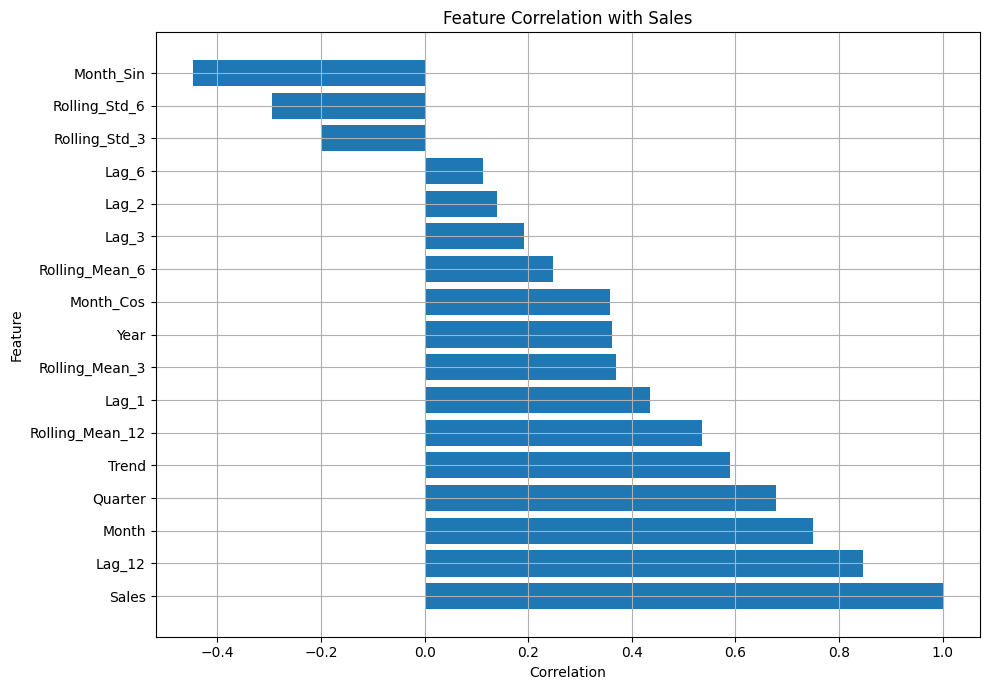

In [54]:
# Correlation Analysis
correlation = ml_df.corr(numeric_only=True)["Sales"].sort_values(
    ascending=False
)

correlation

# Visualize it
plt.figure(figsize=(10, 7))

plt.barh(
    correlation.index,
    correlation.values
)

plt.title("Feature Correlation with Sales")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

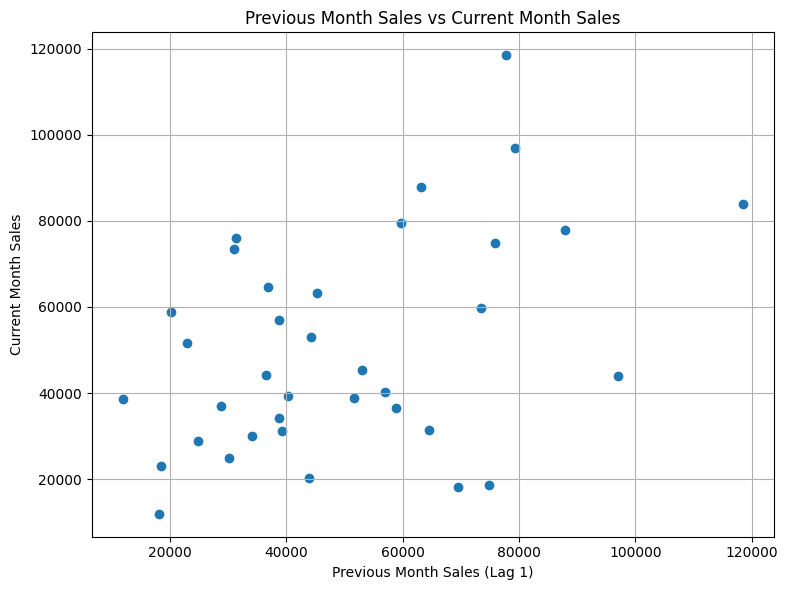

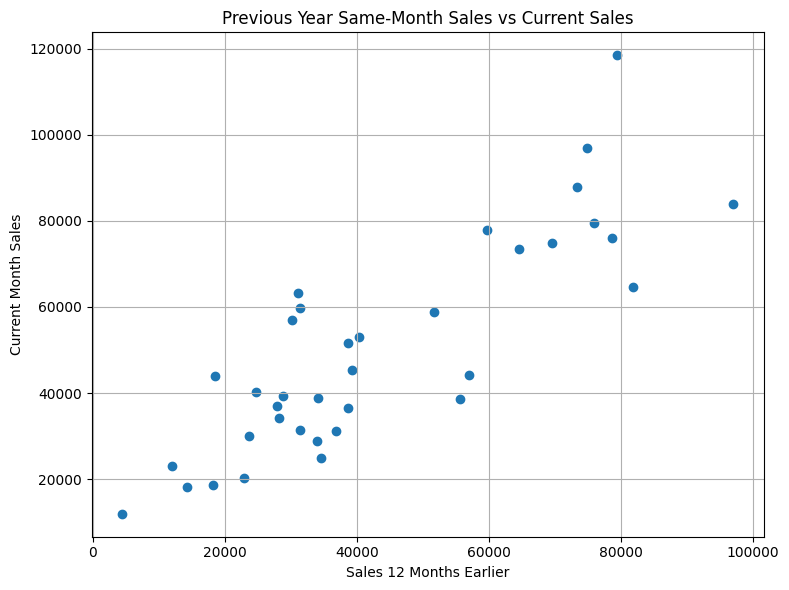

In [55]:
# Visualize Lag 1 vs Sales
plt.figure(figsize=(8, 6))

plt.scatter(
    ml_df["Lag_1"],
    ml_df["Sales"]
)

plt.title("Previous Month Sales vs Current Month Sales")
plt.xlabel("Previous Month Sales (Lag 1)")
plt.ylabel("Current Month Sales")

plt.tight_layout()
plt.show()

# Visualize Lag 12 vs Sales
plt.figure(figsize=(8, 6))

plt.scatter(
    ml_df["Lag_12"],
    ml_df["Sales"]
)

plt.title("Previous Year Same-Month Sales vs Current Sales")
plt.xlabel("Sales 12 Months Earlier")
plt.ylabel("Current Month Sales")

plt.tight_layout()
plt.show()

In [58]:
# Define X and y
feature_columns = [
    "Year",
    "Month",
    "Quarter",
    "Trend",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_6",
    "Lag_12",
    "Rolling_Mean_3",
    "Rolling_Mean_6",
    "Rolling_Mean_12",
    "Rolling_Std_3",
    "Rolling_Std_6",
    "Month_Sin",
    "Month_Cos"
]

X = ml_df[feature_columns]
y = ml_df["Sales"]

# Check
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (36, 16)
y shape: (36,)


In [60]:
# Train / Test split

split_index = int(len(ml_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Check:
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

# Verify the Dates
print("Training period:")
print(ml_df.index[:split_index].min())
print("to")
print(ml_df.index[:split_index].max())

print("\nTesting period:")
print(ml_df.index[split_index:].min())
print("to")
print(ml_df.index[split_index:].max())

Training observations: 28
Testing observations: 8
Training period:
2015-01-01 00:00:00
to
2017-04-01 00:00:00

Testing period:
2017-05-01 00:00:00
to
2017-12-01 00:00:00


In [61]:
# Final Phase 3 Validation
print("=" * 60)
print("PHASE 3 — FEATURE ENGINEERING VALIDATION")
print("=" * 60)

print(f"Total observations: {len(ml_df)}")
print(f"Total features: {len(feature_columns)}")

print("\nFeatures:")
for feature in feature_columns:
    print(f" - {feature}")

print("\nMissing values:")
print(ml_df[feature_columns + ["Sales"]].isnull().sum().sum())

print("\nTraining observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(ml_df.index[:split_index].min().date(),
      "to",
      ml_df.index[:split_index].max().date())

print("\nTesting period:")
print(ml_df.index[split_index:].min().date(),
      "to",
      ml_df.index[split_index:].max().date())

print("=" * 60)
print("PHASE 3 COMPLETED")
print("=" * 60)

PHASE 3 — FEATURE ENGINEERING VALIDATION
Total observations: 36
Total features: 16

Features:
 - Year
 - Month
 - Quarter
 - Trend
 - Lag_1
 - Lag_2
 - Lag_3
 - Lag_6
 - Lag_12
 - Rolling_Mean_3
 - Rolling_Mean_6
 - Rolling_Mean_12
 - Rolling_Std_3
 - Rolling_Std_6
 - Month_Sin
 - Month_Cos

Missing values:
0

Training observations: 28
Testing observations: 8

Training period:
2015-01-01 to 2017-04-01

Testing period:
2017-05-01 to 2017-12-01
PHASE 3 COMPLETED


In [62]:
# ============================================
# PHASE 4: MODEL DEVELOPMENT & FORECASTING
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
# Verify train and test data
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (28, 16)
X_test : (8, 16)
y_train: (28,)
y_test : (8,)


In [67]:
# Establishing base line model
# Before using ML we need to answer, "Can our ML models actually beat a simple forecasting method?"
# We will use a Naive Forecast

#For each month, predict:
# Current month's sales = previous month's sales.

# Since Lag_1 represents the previous month's sales:

naive_predictions = X_test["Lag_1"]
naive_predictions.head()



,Lag_1
Date,
2017-05-01,36521.54
2017-06-01,44261.11
2017-07-01,52981.73
2017-08-01,45264.42
2017-09-01,63120.89


In [68]:
# Evaluate the baseline
def evaluate_model(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted) * 100

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }

# Now evaluate
results = []

results.append(
    evaluate_model(
        y_test,
        naive_predictions,
        "Naive Forecast"
    )
)

results

[{'Model': 'Naive Forecast',
  'MAE': 19019.8590125,
  'RMSE': np.float64(22586.16637232472),
  'MAPE (%)': 24.50663057837912}]

In [69]:
# Train Linear Regression
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

# General predictions
linear_predictions = linear_model.predict(X_test)
linear_predictions[:10]

array([ 63187.99784987,  63056.32906608,  45362.03423398,  49689.43006838,
        73673.33676353,  67762.18243899,  90210.32743097, 100882.84685974])

In [74]:
# Evaluate Linear Regression
results.append(
    evaluate_model(
        y_test,
        linear_predictions,
        "Linear Regression"
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,MAPE (%)
0,Naive Forecast,19019.86,22586.17,24.51
1,Linear Regression,14003.71,15929.78,19.56
2,Linear Regression,14003.71,15929.78,19.56
3,Linear Regression,14003.71,15929.78,19.56
4,Linear Regression,14003.71,15929.78,19.56


In [78]:
# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)



RandomForestRegressor(max_depth=8, min_samples_leaf=2, min_samples_split=3,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [79]:
# Generate predictions
rf_predictions = rf_model.predict(X_test)

In [80]:
# Evaluate Random Forest
results.append(
    evaluate_model(
        y_test,
        rf_predictions,
        "Random Forest"
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,MAPE (%)
0,Naive Forecast,19019.86,22586.17,24.51
1,Linear Regression,14003.71,15929.78,19.56
2,Linear Regression,14003.71,15929.78,19.56
3,Linear Regression,14003.71,15929.78,19.56
4,Linear Regression,14003.71,15929.78,19.56
5,Random Forest,14803.53,18267.13,20.02


In [81]:
# Train Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

GradientBoostingRegressor(learning_rate=0.05, min_samples_leaf=2,
                          min_samples_split=3, n_estimators=200,
                          random_state=42)

In [82]:
# Generate predictions
gb_predictions = gb_model.predict(X_test)

In [83]:
# Evaluate Gradient Boosting
results.append(
    evaluate_model(
        y_test,
        gb_predictions,
        "Gradient Boosting"
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,MAPE (%)
0,Naive Forecast,19019.86,22586.17,24.51
1,Linear Regression,14003.71,15929.78,19.56
2,Linear Regression,14003.71,15929.78,19.56
3,Linear Regression,14003.71,15929.78,19.56
4,Linear Regression,14003.71,15929.78,19.56
5,Random Forest,14803.53,18267.13,20.02
6,Gradient Boosting,16199.47,19445.41,23.01


In [84]:
# Sort by MAE
results_df = results_df.sort_values(
    by="MAE"
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,14003.71,15929.78,19.56
1,Linear Regression,14003.71,15929.78,19.56
2,Linear Regression,14003.71,15929.78,19.56
3,Linear Regression,14003.71,15929.78,19.56
4,Random Forest,14803.53,18267.13,20.02
5,Gradient Boosting,16199.47,19445.41,23.01
6,Naive Forecast,19019.86,22586.17,24.51


In [85]:
# Sort by RMSE
results_df.sort_values("RMSE")

,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,14003.71,15929.78,19.56
1,Linear Regression,14003.71,15929.78,19.56
2,Linear Regression,14003.71,15929.78,19.56
3,Linear Regression,14003.71,15929.78,19.56
4,Random Forest,14803.53,18267.13,20.02
5,Gradient Boosting,16199.47,19445.41,23.01
6,Naive Forecast,19019.86,22586.17,24.51


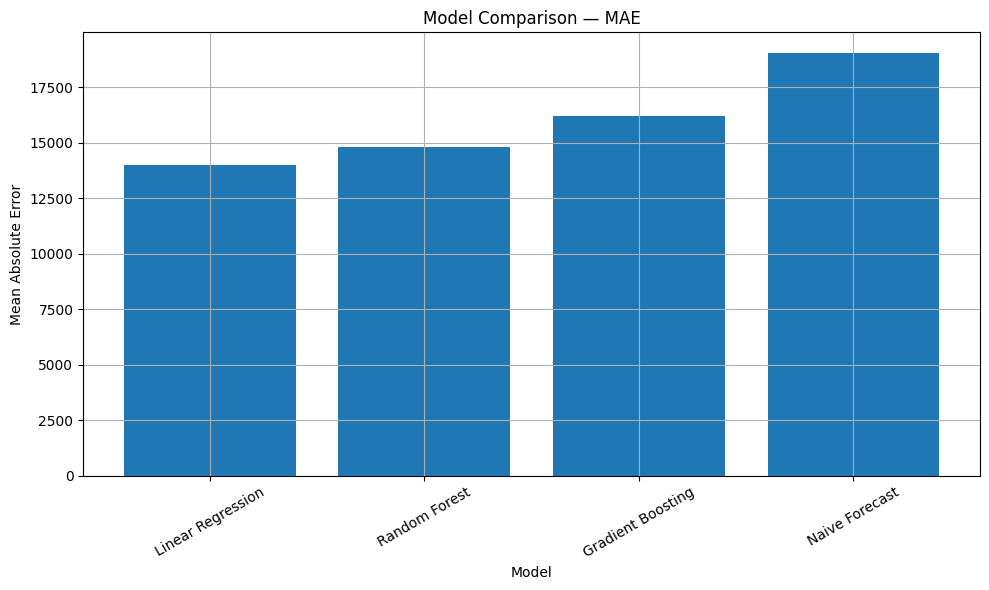

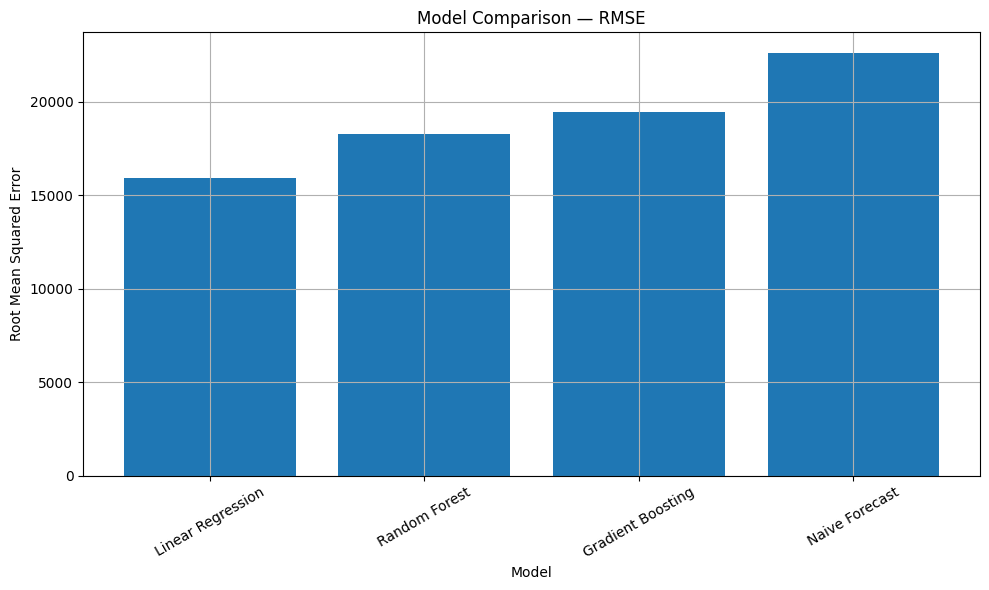

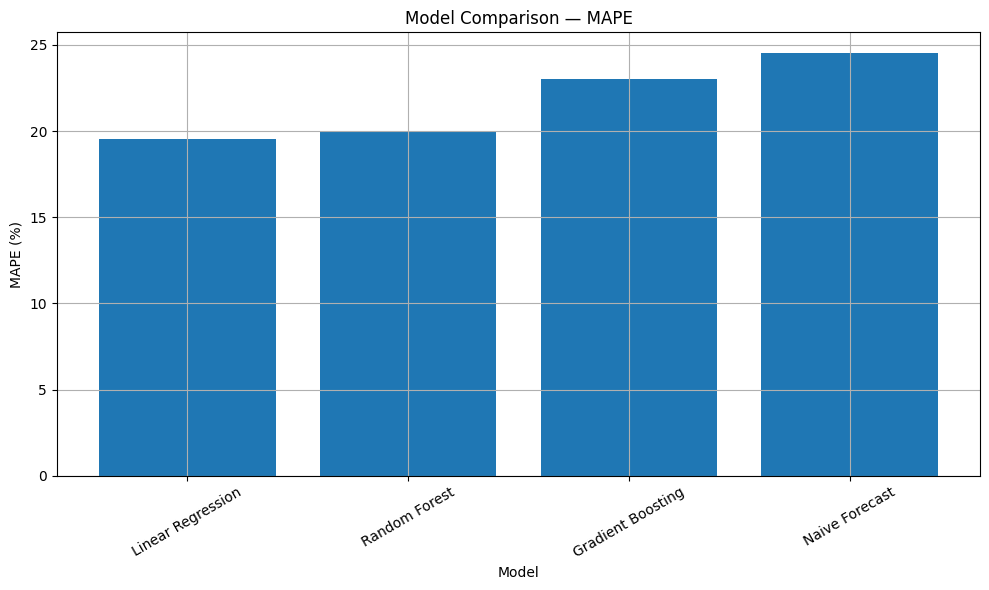

In [86]:
# Compare the models visually

# 1) MAE Comparison
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.title("Model Comparison — MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 2) RMSE Comparison
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("Model Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 3) MAPE Comparison
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["MAPE (%)"]
)

plt.title("Model Comparison — MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [87]:
# Identify Best Model
# MAE as our primary metric

best_model_name = results_df.loc[
    results_df["MAE"].idxmin(),
    "Model"
]

print("Best model based on MAE:", best_model_name)

Best model based on MAE: Linear Regression


In [88]:
# RMSE and MAPE
print("Best model based on RMSE:")

print(
    results_df.loc[
        results_df["RMSE"].idxmin(),
        "Model"
    ]
)

print("\nBest model based on MAPE:")

print(
    results_df.loc[
        results_df["MAPE (%)"].idxmin(),
        "Model"
    ]
)

Best model based on RMSE:
Linear Regression

Best model based on MAPE:
Linear Regression


In [89]:
# Create a Prediction Dataframe
predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Naive Forecast": naive_predictions,
    "Linear Regression": linear_predictions,
    "Random Forest": rf_predictions,
    "Gradient Boosting": gb_predictions
})

predictions_df.head()

,Actual,Naive Forecast,Linear Regression,Random Forest,Gradient Boosting
Date,,,,,
2017-05-01,44261.11,36521.54,63188.00,53533.55,50656.00
2017-06-01,52981.73,44261.11,63056.33,43804.95,42749.92
2017-07-01,45264.42,52981.73,45362.03,40270.29,35493.93
2017-08-01,63120.89,45264.42,49689.43,38146.00,28755.07
2017-09-01,87866.65,63120.89,73673.34,74416.58,83835.83


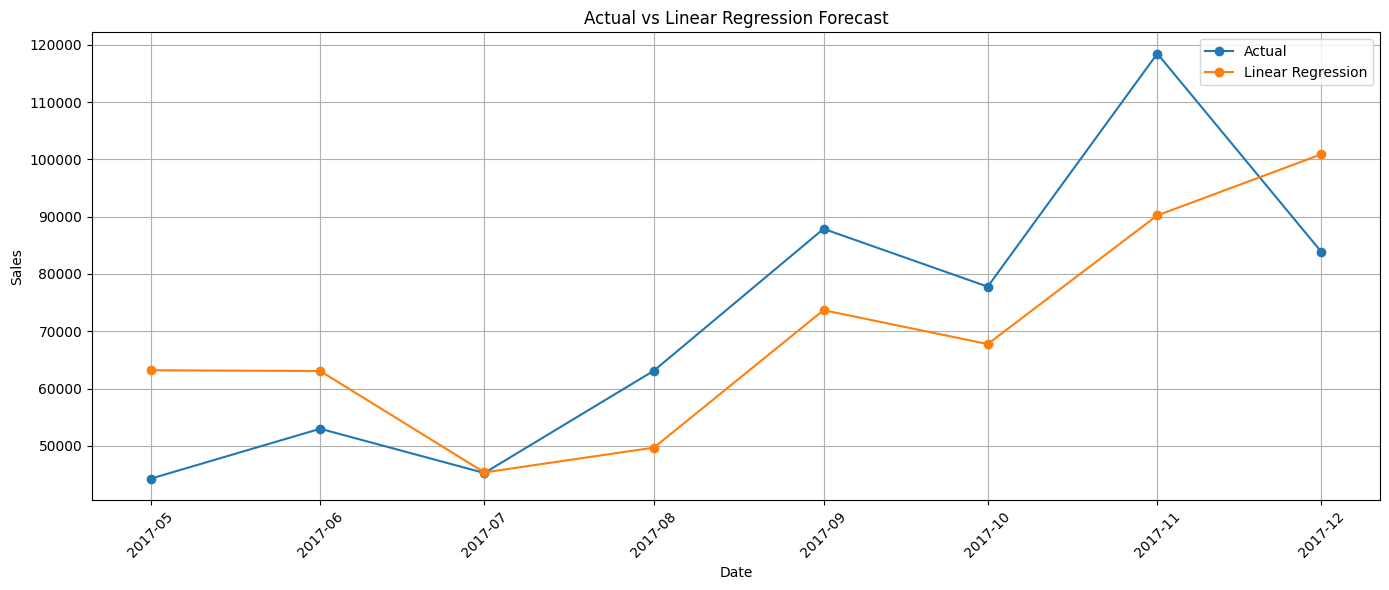

In [90]:
# Plot actual vs predicted values
plt.figure(figsize=(14, 6))

plt.plot(
    predictions_df.index,
    predictions_df["Actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    predictions_df.index,
    predictions_df["Linear Regression"],
    marker="o",
    label="Linear Regression"
)

plt.title("Actual vs Linear Regression Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

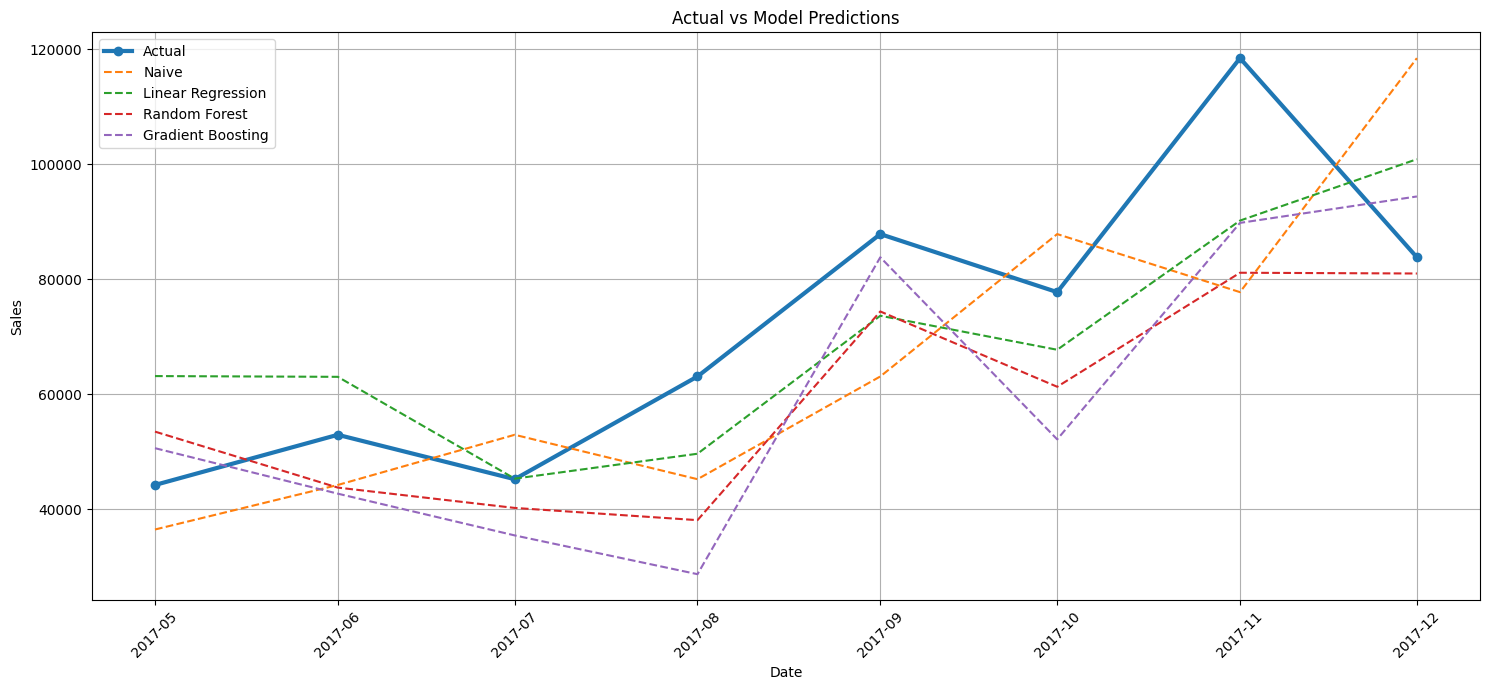

In [91]:
# Compare all Models
plt.figure(figsize=(15, 7))

plt.plot(
    predictions_df.index,
    predictions_df["Actual"],
    marker="o",
    linewidth=3,
    label="Actual"
)

plt.plot(
    predictions_df.index,
    predictions_df["Naive Forecast"],
    linestyle="--",
    label="Naive"
)

plt.plot(
    predictions_df.index,
    predictions_df["Linear Regression"],
    linestyle="--",
    label="Linear Regression"
)

plt.plot(
    predictions_df.index,
    predictions_df["Random Forest"],
    linestyle="--",
    label="Random Forest"
)

plt.plot(
    predictions_df.index,
    predictions_df["Gradient Boosting"],
    linestyle="--",
    label="Gradient Boosting"
)

plt.title("Actual vs Model Predictions")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

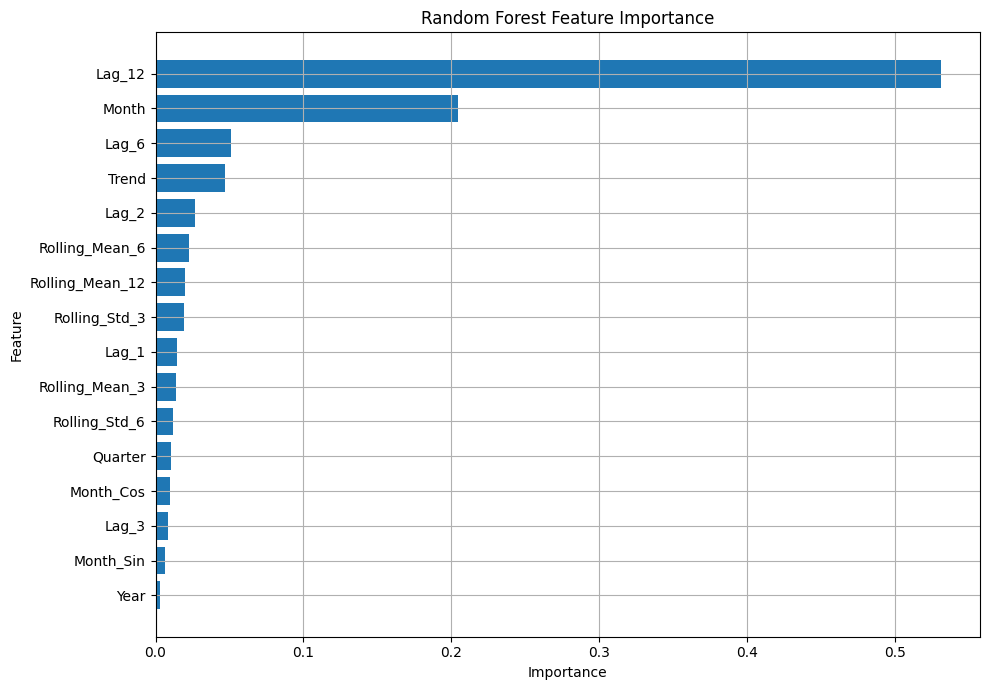

In [92]:
# Feature Importance
# Random Forest

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

# Visualise
plt.figure(figsize=(10, 7))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

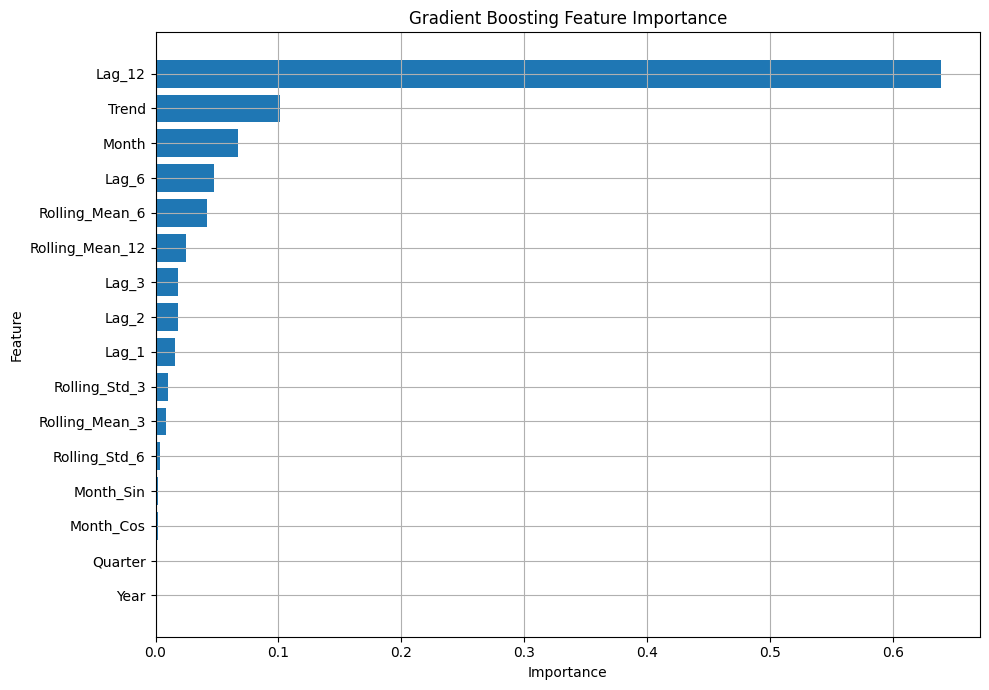

In [93]:
# Gradient Boosting
gb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
})

gb_importance = gb_importance.sort_values(
    by="Importance",
    ascending=False
)

gb_importance

# Visualize
plt.figure(figsize=(10, 7))

plt.barh(
    gb_importance["Feature"],
    gb_importance["Importance"]
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [95]:
# Error Analysis
# Evaluate Model performances and errors
# Lets assume gradient boosting is selected for demonstration

predictions_df["GB_Error"] = (
    predictions_df["Actual"]
    - predictions_df["Gradient Boosting"]
)

# absolute error
predictions_df["GB_Absolute_Error"] = (
    predictions_df["GB_Error"].abs()
)

predictions_df[
    [
        "Actual",
        "Gradient Boosting",
        "GB_Error",
        "GB_Absolute_Error"
    ]
]

,Actual,Gradient Boosting,GB_Error,GB_Absolute_Error
Date,,,,
2017-05-01,44261.11,50656.00,-6394.89,6394.89
2017-06-01,52981.73,42749.92,10231.80,10231.80
2017-07-01,45264.42,35493.93,9770.49,9770.49
2017-08-01,63120.89,28755.07,34365.82,34365.82
2017-09-01,87866.65,83835.83,4030.83,4030.83
2017-10-01,77776.92,52186.82,25590.10,25590.10
2017-11-01,118447.82,89812.75,28635.07,28635.07
2017-12-01,83829.32,94406.07,-10576.75,10576.75


In [97]:
# Find the largest prediction errors
largest_errors = predictions_df.sort_values(
    by="GB_Absolute_Error",
    ascending=False
)

largest_errors[
    [
        "Actual",
        "Gradient Boosting",
        "GB_Error",
        "GB_Absolute_Error"
    ]
].head(10)

,Actual,Gradient Boosting,GB_Error,GB_Absolute_Error
Date,,,,
2017-08-01,63120.89,28755.07,34365.82,34365.82
2017-11-01,118447.82,89812.75,28635.07,28635.07
2017-10-01,77776.92,52186.82,25590.10,25590.10
2017-12-01,83829.32,94406.07,-10576.75,10576.75
2017-06-01,52981.73,42749.92,10231.80,10231.80
2017-07-01,45264.42,35493.93,9770.49,9770.49
2017-05-01,44261.11,50656.00,-6394.89,6394.89
2017-09-01,87866.65,83835.83,4030.83,4030.83


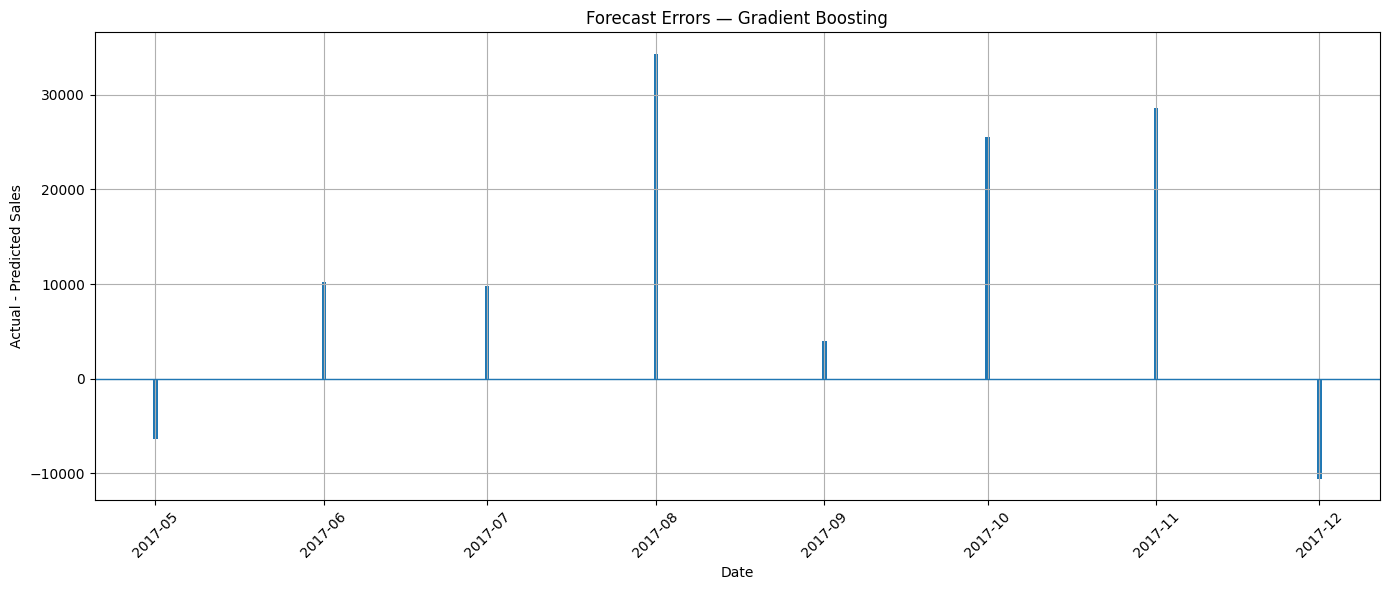

In [98]:
# Plot Forecast errors
plt.figure(figsize=(14, 6))

plt.bar(
    predictions_df.index,
    predictions_df["GB_Error"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Forecast Errors — Gradient Boosting")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [99]:
# Calculate Percentage errors
predictions_df["GB_Percentage_Error"] = (
    predictions_df["GB_Error"]
    / predictions_df["Actual"]
) * 100

predictions_df[
    [
        "Actual",
        "Gradient Boosting",
        "GB_Percentage_Error"
    ]
]

,Actual,Gradient Boosting,GB_Percentage_Error
Date,,,
2017-05-01,44261.11,50656.00,-14.45
2017-06-01,52981.73,42749.92,19.31
2017-07-01,45264.42,35493.93,21.59
2017-08-01,63120.89,28755.07,54.44
2017-09-01,87866.65,83835.83,4.59
2017-10-01,77776.92,52186.82,32.90
2017-11-01,118447.82,89812.75,24.18
2017-12-01,83829.32,94406.07,-12.62


In [100]:
# Final Model Evaluation
final_results = results_df.copy()

final_results

,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,14003.71,15929.78,19.56
1,Linear Regression,14003.71,15929.78,19.56
2,Linear Regression,14003.71,15929.78,19.56
3,Linear Regression,14003.71,15929.78,19.56
4,Random Forest,14803.53,18267.13,20.02
5,Gradient Boosting,16199.47,19445.41,23.01
6,Naive Forecast,19019.86,22586.17,24.51


In [101]:
final_results["MAE"] = final_results["MAE"].round(2)
final_results["RMSE"] = final_results["RMSE"].round(2)
final_results["MAPE (%)"] = final_results["MAPE (%)"].round(2)

final_results

,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,14003.71,15929.78,19.56
1,Linear Regression,14003.71,15929.78,19.56
2,Linear Regression,14003.71,15929.78,19.56
3,Linear Regression,14003.71,15929.78,19.56
4,Random Forest,14803.53,18267.13,20.02
5,Gradient Boosting,16199.47,19445.41,23.01
6,Naive Forecast,19019.86,22586.17,24.51


In [102]:
# ============================================
# PHASE 5: FUTURE FORECASTING &
# BUSINESS VISUALIZATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [104]:
# Identify best model
best_model_name = results_df.loc[
    results_df["MAE"].idxmin(),
    "Model"
]

print("Selected Best Model:", best_model_name)

# Display metrics
best_model_metrics = results_df[
    results_df["Model"] == best_model_name
]

best_model_metrics

Selected Best Model: Linear Regression


,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,14003.71,15929.78,19.56
1,Linear Regression,14003.71,15929.78,19.56
2,Linear Regression,14003.71,15929.78,19.56
3,Linear Regression,14003.71,15929.78,19.56


In [106]:
# Map the model name to the trained model
trained_models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

if best_model_name != "Naive Forecast":
    best_model = trained_models[best_model_name]
else:
    best_model = None

print("Final selected model:", best_model_name)

Final selected model: Linear Regression


In [107]:
historical_sales = forecast_df.copy()

historical_sales = historical_sales.rename(
    columns={"Sales": "Actual Sales"}
)

historical_sales.head()

,Actual Sales
Date,
2014-01-01,14236.90
2014-02-01,4519.89
2014-03-01,55691.01
2014-04-01,28295.35
2014-05-01,23648.29


In [108]:
# Determine the forecast horizon
FORECAST_HORIZON = 12

print(
    f"Forecast horizon: {FORECAST_HORIZON} months"
)

Forecast horizon: 12 months


In [110]:
# Generate Future Dates
last_date = forecast_df.index.max()

print("Last historical date:", last_date)

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=FORECAST_HORIZON,
    freq="MS"
)

future_dates

Last historical date: 2017-12-01 00:00:00


DatetimeIndex(['2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01',
               '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [111]:
# Create a recursive forecasting function
def create_features_for_date(date, sales_history):
    """
    Create forecasting features using only
    information available before the forecast date.
    """

    month = date.month
    year = date.year
    quarter = date.quarter

    trend = len(sales_history) + 1

    # Lag features
    lag_1 = sales_history.iloc[-1]
    lag_2 = sales_history.iloc[-2]
    lag_3 = sales_history.iloc[-3]
    lag_6 = sales_history.iloc[-6]
    lag_12 = sales_history.iloc[-12]

    # Rolling features
    rolling_mean_3 = sales_history.iloc[-3:].mean()
    rolling_mean_6 = sales_history.iloc[-6:].mean()
    rolling_mean_12 = sales_history.iloc[-12:].mean()

    rolling_std_3 = sales_history.iloc[-3:].std()
    rolling_std_6 = sales_history.iloc[-6:].std()

    # Cyclical month features
    month_sin = np.sin(
        2 * np.pi * month / 12
    )

    month_cos = np.cos(
        2 * np.pi * month / 12
    )

    return pd.DataFrame({
        "Year": [year],
        "Month": [month],
        "Quarter": [quarter],
        "Trend": [trend],
        "Lag_1": [lag_1],
        "Lag_2": [lag_2],
        "Lag_3": [lag_3],
        "Lag_6": [lag_6],
        "Lag_12": [lag_12],
        "Rolling_Mean_3": [rolling_mean_3],
        "Rolling_Mean_6": [rolling_mean_6],
        "Rolling_Mean_12": [rolling_mean_12],
        "Rolling_Std_3": [rolling_std_3],
        "Rolling_Std_6": [rolling_std_6],
        "Month_Sin": [month_sin],
        "Month_Cos": [month_cos]
    })

In [112]:
# Generate Recursive Future Prediction
sales_history = forecast_df["Sales"].copy()

future_predictions = []

# Forecast month by month
for date in future_dates:

    features = create_features_for_date(
        date,
        sales_history
    )

    if best_model_name == "Naive Forecast":

        prediction = sales_history.iloc[-1]

    else:

        prediction = best_model.predict(
            features[feature_columns]
        )[0]

    future_predictions.append(prediction)

    # Add prediction to history so it can
    # be used for the next forecast
    sales_history.loc[date] = prediction

In [113]:
# Future Forecast Dataframe
future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecast Sales": future_predictions
})

future_forecast = future_forecast.set_index("Date")

future_forecast

,Forecast Sales
Date,
2018-01-01,52403.93
2018-02-01,34826.39
2018-03-01,70425.87
2018-04-01,54825.02
2018-05-01,61077.77
2018-06-01,52908.87
2018-07-01,48166.50
2018-08-01,63571.00
2018-09-01,83391.54


In [114]:
# Check for invalid Predictions
negative_predictions = (
    future_forecast["Forecast Sales"] < 0
).sum()

print(
    "Negative forecast values:",
    negative_predictions
)

Negative forecast values: 0


In [115]:
# Calculate expected total Future sales
total_forecast_sales = (
    future_forecast["Forecast Sales"].sum()
)

print(
    f"Forecasted sales for next 12 months: "
    f"${total_forecast_sales:,.2f}"
)

# Calculate average monthly forecast
average_forecast_sales = (
    future_forecast["Forecast Sales"].mean()
)

print(
    f"Average forecasted monthly sales: "
    f"${average_forecast_sales:,.2f}"
)

# Find the highest forecast month
highest_forecast_month = (
    future_forecast["Forecast Sales"]
    .idxmax()
)

highest_forecast_value = (
    future_forecast.loc[
        highest_forecast_month,
        "Forecast Sales"
    ]
)

print("Highest forecast month:",
      highest_forecast_month.strftime("%B %Y"))

print(
    f"Forecasted sales: "
    f"${highest_forecast_value:,.2f}"
)

# Find the lowest forecast month
lowest_forecast_month = (
    future_forecast["Forecast Sales"]
    .idxmin()
)

lowest_forecast_value = (
    future_forecast.loc[
        lowest_forecast_month,
        "Forecast Sales"
    ]
)

print("Lowest forecast month:",
      lowest_forecast_month.strftime("%B %Y"))

print(
    f"Forecasted sales: "
    f"${lowest_forecast_value:,.2f}"
)

# Combine historical and future forecast
combined_forecast = pd.concat([
    historical_sales,
    future_forecast.rename(
        columns={"Forecast Sales": "Actual Sales"}
    )
])

combined_forecast.tail(20)



Forecasted sales for next 12 months: $818,943.44
Average forecasted monthly sales: $68,245.29
Highest forecast month: November 2018
Forecasted sales: $114,844.86
Lowest forecast month: February 2018
Forecasted sales: $34,826.39


,Actual Sales
Date,
2017-05-01,44261.11
2017-06-01,52981.73
2017-07-01,45264.42
2017-08-01,63120.89
2017-09-01,87866.65
2017-10-01,77776.92
2017-11-01,118447.82
2017-12-01,83829.32
2018-01-01,52403.93


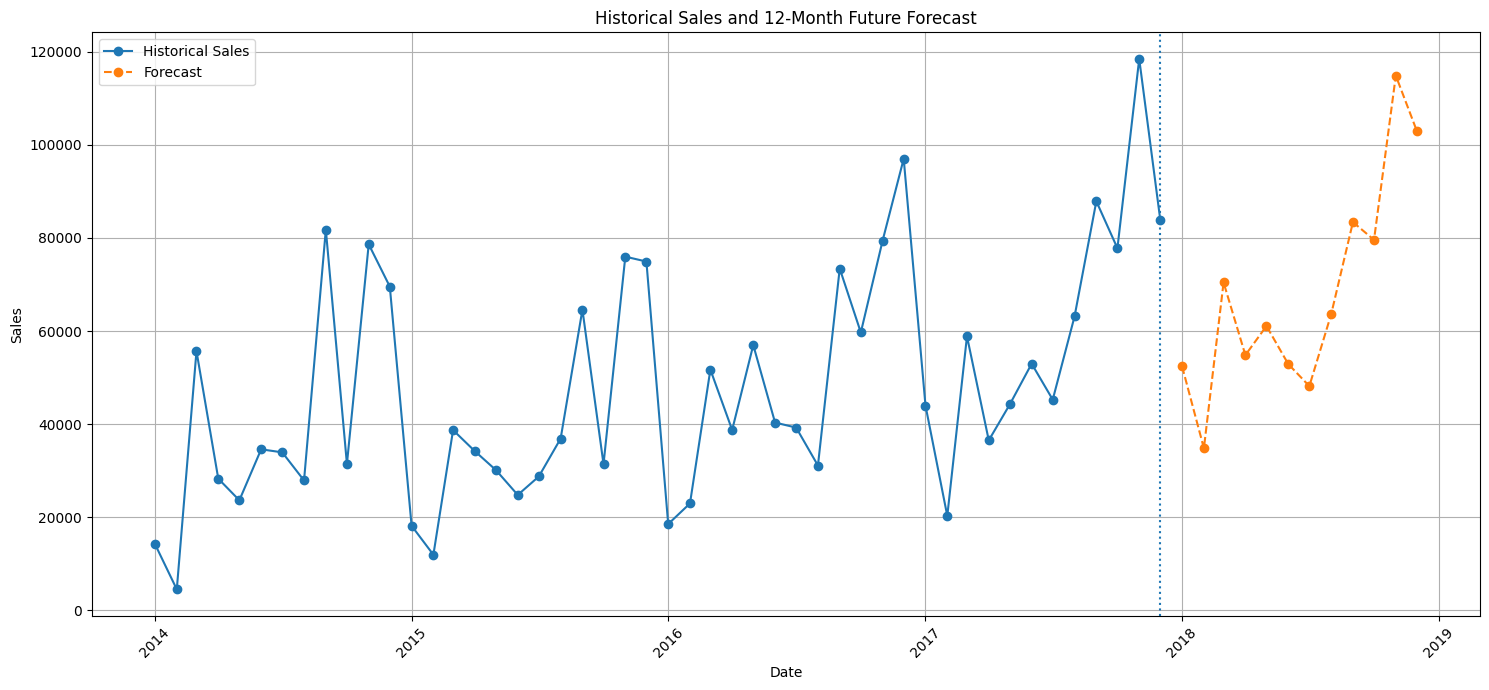

In [116]:
# Create the main Business Forecast Chart
plt.figure(figsize=(15, 7))

plt.plot(
    historical_sales.index,
    historical_sales["Actual Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    future_forecast.index,
    future_forecast["Forecast Sales"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.axvline(
    x=historical_sales.index.max(),
    linestyle=":"
)

plt.title(
    "Historical Sales and 12-Month Future Forecast"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [118]:
# Add a forecast Table
forecast_table = future_forecast.copy()

forecast_table["Forecast Sales"] = (
    forecast_table["Forecast Sales"]
    .round(2)
)

forecast_table

# Calculate forecast growth
historical_average = (
    forecast_df["Sales"].mean()
)

forecast_average = (
    future_forecast["Forecast Sales"].mean()
)

forecast_growth = (
    (forecast_average - historical_average)
    / historical_average
) * 100

print(
    f"Historical average monthly sales: "
    f"${historical_average:,.2f}"
)

print(
    f"Forecast average monthly sales: "
    f"${forecast_average:,.2f}"
)

print(
    f"Expected change: "
    f"{forecast_growth:.2f}%"
)

Historical average monthly sales: $47,858.35
Forecast average monthly sales: $68,245.29
Expected change: 42.60%


In [120]:
# Compare forecast with previous year
last_12_months = forecast_df.tail(12).copy()

last_12_months

,Sales
Date,
2017-01-01,43971.37
2017-02-01,20301.13
2017-03-01,58872.35
2017-04-01,36521.54
2017-05-01,44261.11
2017-06-01,52981.73
2017-07-01,45264.42
2017-08-01,63120.89
2017-09-01,87866.65


In [121]:
previous_year_total = (
    last_12_months["Sales"].sum()
)

forecast_year_total = (
    future_forecast["Forecast Sales"].sum()
)

year_over_year_forecast_growth = (
    (forecast_year_total - previous_year_total)
    / previous_year_total
) * 100

print(
    f"Previous 12-month sales: "
    f"${previous_year_total:,.2f}"
)

print(
    f"Forecast next 12-month sales: "
    f"${forecast_year_total:,.2f}"
)

print(
    f"Expected year-over-year change: "
    f"{year_over_year_forecast_growth:.2f}%"
)

Previous 12-month sales: $733,215.26
Forecast next 12-month sales: $818,943.44
Expected year-over-year change: 11.69%


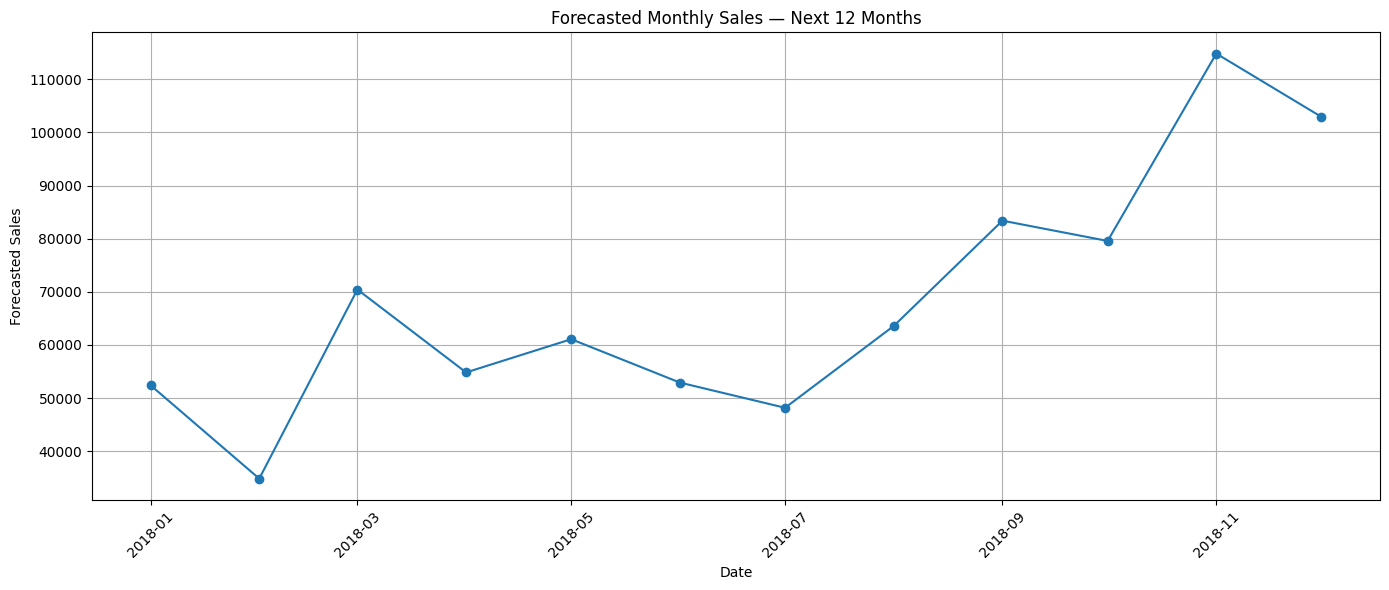

In [122]:
# Create a forecast only visualization
plt.figure(figsize=(14, 6))

plt.plot(
    future_forecast.index,
    future_forecast["Forecast Sales"],
    marker="o"
)

plt.title("Forecasted Monthly Sales — Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

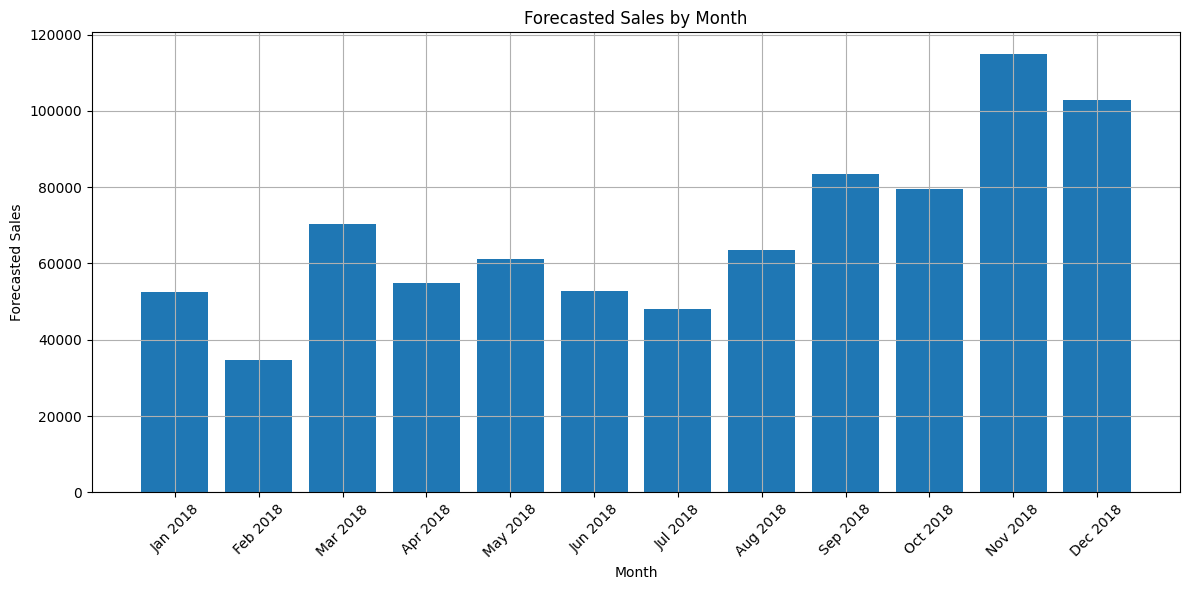

In [123]:
# Forecast by month
plt.figure(figsize=(12, 6))

plt.bar(
    future_forecast.index.strftime("%b %Y"),
    future_forecast["Forecast Sales"]
)

plt.title("Forecasted Sales by Month")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [124]:
# Forecaste summary
forecast_summary = pd.DataFrame({
    "Metric": [
        "Selected Model",
        "Forecast Horizon",
        "Historical Average Monthly Sales",
        "Forecast Average Monthly Sales",
        "Previous 12-Month Sales",
        "Forecast Next 12-Month Sales",
        "Expected YoY Change",
        "Highest Forecast Month",
        "Lowest Forecast Month"
    ],
    "Value": [
        best_model_name,
        "12 months",
        f"${historical_average:,.2f}",
        f"${forecast_average:,.2f}",
        f"${previous_year_total:,.2f}",
        f"${forecast_year_total:,.2f}",
        f"{year_over_year_forecast_growth:.2f}%",
        highest_forecast_month.strftime("%B %Y"),
        lowest_forecast_month.strftime("%B %Y")
    ]
})

forecast_summary

,Metric,Value
0,Selected Model,Linear Regression
1,Forecast Horizon,12 months
2,Historical Average Monthly Sales,"$47,858.35"
3,Forecast Average Monthly Sales,"$68,245.29"
4,Previous 12-Month Sales,"$733,215.26"
5,Forecast Next 12-Month Sales,"$818,943.44"
6,Expected YoY Change,11.69%
7,Highest Forecast Month,November 2018
8,Lowest Forecast Month,February 2018


In [128]:
# Save the forecast
future_forecast.to_csv(
    "results/future_sales_forecast.csv"
)

forecast_summary.to_csv(
    "results/forecast_summary.csv",
    index=False
)

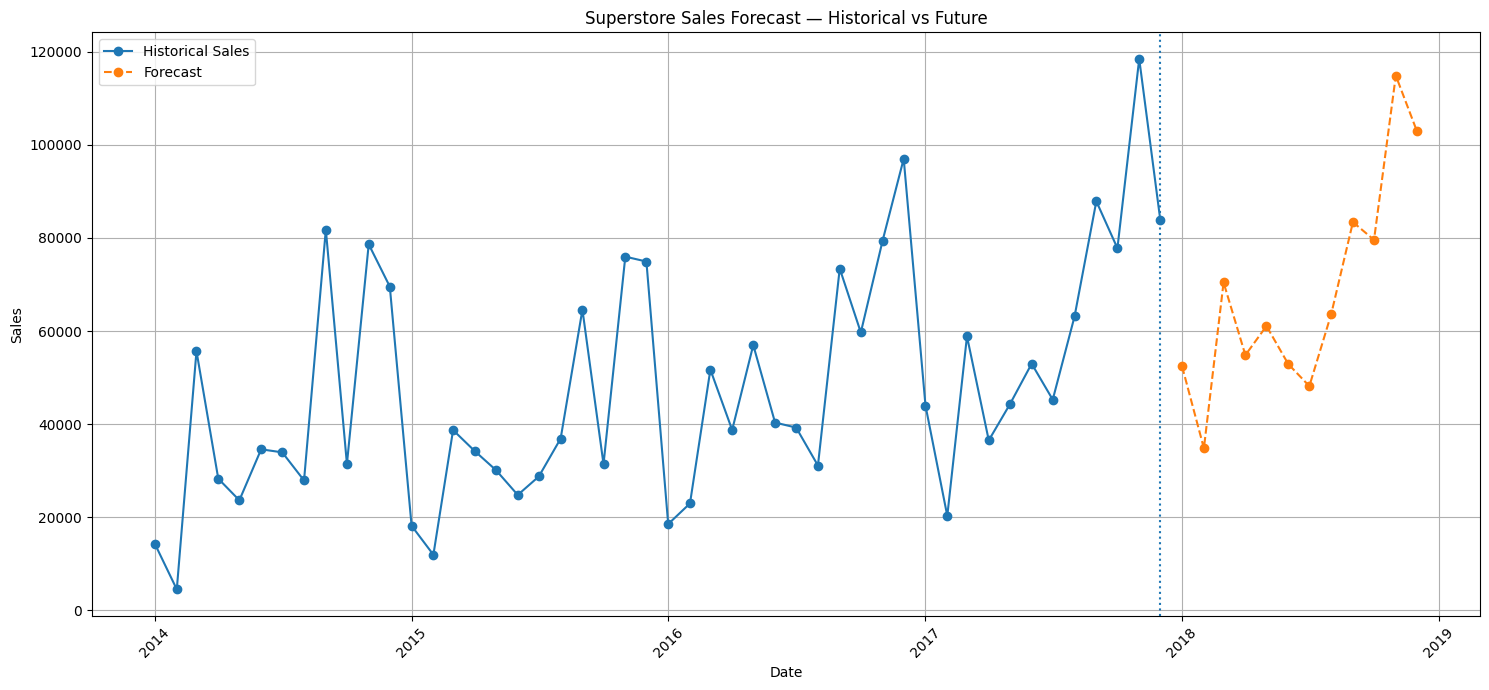

In [130]:
# Save main forecast Graph
plt.figure(figsize=(15, 7))

plt.plot(
    historical_sales.index,
    historical_sales["Actual Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    future_forecast.index,
    future_forecast["Forecast Sales"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.axvline(
    x=historical_sales.index.max(),
    linestyle=":"
)

plt.title(
    "Superstore Sales Forecast — Historical vs Future"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "visualizations/final_sales_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [131]:
# Generate Business Insights
first_year_sales = (
    yearly_sales.iloc[0]["Sales"]
)

last_year_sales = (
    yearly_sales.iloc[-1]["Sales"]
)

historical_growth = (
    (last_year_sales - first_year_sales)
    / first_year_sales
) * 100

print(
    f"Sales growth from first to last year: "
    f"{historical_growth:.2f}%"
)

Sales growth from first to last year: 51.41%


In [132]:
# Best Category
best_category = category_sales.iloc[0]

print(
    f"Top sales category: "
    f"{best_category['Category']}"
)

print(
    f"Sales: "
    f"${best_category['Sales']:,.2f}"
)

# Best Region
best_region = region_sales.iloc[0]

print(
    f"Top sales region: "
    f"{best_region['Region']}"
)

print(
    f"Sales: "
    f"${best_region['Sales']:,.2f}"
)

Top sales category: Technology
Sales: $836,154.03
Top sales region: West
Sales: $725,457.82


In [133]:
# Final Phase 5 Validation
print("=" * 65)
print("PHASE 5 — FINAL FORECAST VALIDATION")
print("=" * 65)

print(f"Selected Model: {best_model_name}")

print(
    f"Forecast Period: "
    f"{future_forecast.index.min().date()} "
    f"to "
    f"{future_forecast.index.max().date()}"
)

print(
    f"Forecast Horizon: "
    f"{len(future_forecast)} months"
)

print(
    f"Total Forecasted Sales: "
    f"${future_forecast['Forecast Sales'].sum():,.2f}"
)

print(
    f"Average Monthly Forecast: "
    f"${future_forecast['Forecast Sales'].mean():,.2f}"
)

print(
    f"Expected YoY Change: "
    f"{year_over_year_forecast_growth:.2f}%"
)

print(
    f"Highest Forecast Month: "
    f"{highest_forecast_month.strftime('%B %Y')}"
)

print(
    f"Lowest Forecast Month: "
    f"{lowest_forecast_month.strftime('%B %Y')}"
)

print(
    f"Negative Predictions: "
    f"{negative_predictions}"
)

print("=" * 65)
print("PHASE 5 COMPLETED")
print("=" * 65)

PHASE 5 — FINAL FORECAST VALIDATION
Selected Model: Linear Regression
Forecast Period: 2018-01-01 to 2018-12-01
Forecast Horizon: 12 months
Total Forecasted Sales: $818,943.44
Average Monthly Forecast: $68,245.29
Expected YoY Change: 11.69%
Highest Forecast Month: November 2018
Lowest Forecast Month: February 2018
Negative Predictions: 0
PHASE 5 COMPLETED
